# 00. Exploratory Data Analysis — H&M Fashion Recommendations

## Table of Contents

1. [Data Loading & Overview](#1-Data-Loading-&-Overview)
   - Schema · Dataset Summary · **Data Quality & Nulls**
2. [Article Analysis](#2-Article-Analysis)
   - Attribute Distributions · SKU Structure · Category Hierarchy · **detail_desc Text Quality** · **Product Lifecycle**
3. [Customer Analysis](#3-Customer-Analysis)
   - Demographics · Club Status · Segmentation · **Age × Category Preference**
4. [Transaction Analysis](#4-Transaction-Analysis)
   - Time Series · Temporal Decomposition · Price Analysis · **Seasonal Category Variation** · **Basket Analysis**
5. [User Behavior Analysis](#5-User-Behavior-Analysis)
   - Purchase Distribution · Cold-start & Sparsity · Preference & Co-purchase
6. [Item Popularity Analysis](#6-Item-Popularity-Analysis)
   - Rank-Frequency · Pareto Curve · Coverage Statistics
7. [Temporal Split Validation](#7-Temporal-Split-Validation)
   - Split Visualization · **User/Item Overlap** · **Recency Distribution**
8. [Image Data Summary](#8-Image-Data-Summary)
9. [Key Findings Summary](#9-Key-Findings-Summary)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Project root (1 level up from notebooks/)
PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Data paths
DATA_DIR = PROJECT_ROOT / "data" / "h-and-m-personalized-fashion-recommendations"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Results paths
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

# Create directories if needed
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

# Theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Domain color constants
COLORS = {
    'count': 'steelblue', 'monetary': '#e67e22', 'accent': '#e74c3c',
    'muted': '#95a5a6', 'null': 'lightcoral',
}
INDEX_COLORS = {
    'Ladieswear': '#e41a1c', 'Menswear': '#377eb8', 'Divided': '#4daf4a',
    'Baby/Children': '#ff7f00', 'Sport': '#984ea3',
}
CHANNEL_COLORS = {1: '#3498db', 2: '#e74c3c'}  # Online / In-store


def plot_top_n_barh(ax, series, *, n=15, color='steelblue', title='', xlabel='Count'):
    """Horizontal bar + percent annotations (dunnhumby pattern)."""
    top = series.nlargest(n).iloc[::-1]
    total = series.sum()
    bars = ax.barh(top.index.astype(str), top.values, color=color, alpha=0.8)
    for bar, val in zip(bars, top.values):
        pct = val / total * 100
        ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:,} ({pct:.1f}%)', va='center', fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))


def plot_hist_with_stats(ax, data, *, bins=50, color='steelblue', title='',
                         xlabel='', show_kde=True):
    """Histogram + KDE + mean/median axvline + quartile shading."""
    data = data.dropna()
    sns.histplot(data, bins=bins, color=color, alpha=0.8, edgecolor='white',
                 kde=show_kde, ax=ax, stat='count')
    mean_val, med_val = data.mean(), data.median()
    q25, q75 = data.quantile(0.25), data.quantile(0.75)
    _fmt = '.4f' if abs(mean_val) < 1 else ('.1f' if abs(mean_val) < 1000 else ',.0f')
    ax.axvspan(q25, q75, alpha=0.08, color='gray', label=f'IQR [{q25:{_fmt}}, {q75:{_fmt}}]')
    ax.axvline(med_val, color='red', linestyle='--', alpha=0.7, lw=1.5,
               label=f'Median = {med_val:{_fmt}}')
    ax.axvline(mean_val, color='orange', linestyle='--', alpha=0.7, lw=1.5,
               label=f'Mean = {mean_val:{_fmt}}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)


def plot_ecdf_with_quantiles(ax, data, *, quantiles=(0.5, 0.75, 0.9), title='', xlabel=''):
    """ECDF + quantile annotation lines (rtb_ipinyou CDF pattern)."""
    data_sorted = np.sort(data.dropna().values)
    ecdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    ax.plot(data_sorted, ecdf, color=COLORS['count'], lw=1.5)
    colors_q = ['#e74c3c', '#e67e22', '#27ae60', '#8e44ad']
    for q, c in zip(quantiles, colors_q):
        val = np.percentile(data_sorted, q * 100)
        ax.axhline(q, color=c, linestyle=':', alpha=0.5, lw=1)
        ax.axvline(val, color=c, linestyle='--', alpha=0.7, lw=1.2)
        ax.annotate(f'P{int(q*100)}={val:.0f}', xy=(val, q),
                    xytext=(10, 5), textcoords='offset points', fontsize=8,
                    color=c, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Cumulative Probability')
    ax.set_ylim(0, 1.02)


con = duckdb.connect()

## 1. Data Loading & Overview

### Feature Descriptions

**articles.csv** — 상품 메타데이터 (105,542 SKUs, 25 columns)

| Column | Description |
|--------|-------------|
| `article_id` | 고유 SKU 식별자 (9자리 정수) |
| `product_code` | 상위 제품 코드 — 동일 제품의 색상/사이즈 변형이 같은 코드 공유 |
| `prod_name` | 제품명 (e.g., "Strap top") |
| `product_type_no` / `product_type_name` | 제품 유형 코드 및 명칭 (e.g., 253 / "Vest top") |
| `product_group_name` | 제품 그룹 (e.g., "Garment Upper body", "Accessories") |
| `graphical_appearance_no` / `graphical_appearance_name` | 그래픽 외관 코드 및 명칭 (e.g., "Solid", "Stripe") |
| `colour_group_code` / `colour_group_name` | 색상 그룹 코드 및 명칭 (e.g., "Black", "White") |
| `perceived_colour_value_id` / `perceived_colour_value_name` | 체감 색상 명도 (e.g., "Dark", "Light", "Dusty") |
| `perceived_colour_master_id` / `perceived_colour_master_name` | 체감 색상 대분류 (e.g., "Black", "Blue", "Red") |
| `department_no` / `department_name` | 부서 코드 및 명칭 — 내부 조직 분류 |
| `index_code` / `index_name` | 인덱스 코드 및 명칭 (e.g., "A" / "Ladieswear") |
| `index_group_no` / `index_group_name` | 인덱스 그룹 (e.g., "Ladieswear", "Baby/Children") |
| `section_no` / `section_name` | 섹션 코드 및 명칭 — 매장 내 배치 구역 |
| `garment_group_no` / `garment_group_name` | 의류 그룹 코드 및 명칭 (e.g., "Jersey Basic") |
| `detail_desc` | 상품 상세 설명 텍스트 — L1 속성 추출의 핵심 입력 |

**customers.csv** — 고객 정보 (1,371,980 rows, 7 columns)

| Column | Description |
|--------|-------------|
| `customer_id` | 고유 고객 식별자 (64자리 해시) |
| `FN` | Fashion News 수신 동의 여부 (1.0 / NaN) |
| `Active` | 활성 상태 여부 (1.0 / NaN) |
| `club_member_status` | 멤버십 상태 (ACTIVE, PRE-CREATE, LEFT CLUB 등) |
| `fashion_news_frequency` | 패션 뉴스 수신 빈도 (Regularly, Monthly, NONE 등) |
| `age` | 나이 (연속형, 결측치 존재) |
| `postal_code` | 우편번호 해시 — 지역 기반 분석용 |

**transactions_train.csv** — 구매 이력 (31,788,324 rows, 5 columns)

| Column | Description |
|--------|-------------|
| `t_dat` | 거래 일자 (YYYY-MM-DD, 2018-09 ~ 2020-09) |
| `customer_id` | 구매 고객 ID (→ customers.csv FK) |
| `article_id` | 구매 상품 ID (→ articles.csv FK) |
| `price` | 정규화된 가격 (Kaggle에서 상수로 나눈 값, ~0.01–0.06 범위) |
| `sales_channel_id` | 판매 채널 (1=Online, 2=In-store) |

In [2]:
for name, fname in [("articles", "articles.csv"), ("customers", "customers.csv"),
                     ("transactions", "transactions_train.csv")]:
    n = con.execute(f"SELECT COUNT(*) FROM read_csv_auto('{DATA_DIR / fname}')").fetchone()[0]
    print(f"{name}: {n:,} rows")
    schema = con.execute(f"DESCRIBE SELECT * FROM read_csv_auto('{DATA_DIR / fname}')").df()
    display(schema)

# Dataset summary statistics
n_articles = con.execute(
    f"SELECT COUNT(*) FROM read_csv_auto('{DATA_DIR}/articles.csv')"
).fetchone()[0]
n_products = con.execute(
    f"SELECT COUNT(DISTINCT product_code) FROM read_csv_auto('{DATA_DIR}/articles.csv')"
).fetchone()[0]
avg_var = n_articles / n_products
n_customers = con.execute(
    f"SELECT COUNT(*) FROM read_csv_auto('{DATA_DIR}/customers.csv')"
).fetchone()[0]
n_transactions = con.execute(
    f"SELECT COUNT(*) FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')"
).fetchone()[0]
min_date, max_date = con.execute(
    f"SELECT MIN(t_dat), MAX(t_dat) FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')"
).fetchone()
n_pairs = con.execute(f"""
    SELECT COUNT(*) FROM (
        SELECT DISTINCT customer_id, article_id
        FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    )
""").fetchone()[0]
sparsity = 1 - n_pairs / (n_customers * n_articles)

print(f"\nDataset Summary")
print(f"{'='*60}")
print(f"Articles (SKUs): {n_articles:,}  |  Products (parent): {n_products:,}  |  Avg variants: {avg_var:.1f}")
print(f"Customers: {n_customers:,}  |  Transactions: {n_transactions:,}")
print(f"Period: {min_date} ~ {max_date}")
print(f"Sparsity: {sparsity:.6%}")

articles: 105,542 rows


,column_name,column_type,null,key,default,extra
0,article_id,VARCHAR,YES,None,None,None
1,product_code,VARCHAR,YES,None,None,None
2,prod_name,VARCHAR,YES,None,None,None
3,product_type_no,BIGINT,YES,None,None,None
4,product_type_name,VARCHAR,YES,None,None,None
5,product_group_name,VARCHAR,YES,None,None,None
6,graphical_appearance_no,BIGINT,YES,None,None,None
7,graphical_appearance_name,VARCHAR,YES,None,None,None
8,colour_group_code,VARCHAR,YES,None,None,None
9,colour_group_name,VARCHAR,YES,None,None,None


customers: 1,371,980 rows


,column_name,column_type,null,key,default,extra
0,customer_id,VARCHAR,YES,None,None,None
1,FN,DOUBLE,YES,None,None,None
2,Active,DOUBLE,YES,None,None,None
3,club_member_status,VARCHAR,YES,None,None,None
4,fashion_news_frequency,VARCHAR,YES,None,None,None
5,age,BIGINT,YES,None,None,None
6,postal_code,VARCHAR,YES,None,None,None


transactions: 31,788,324 rows


,column_name,column_type,null,key,default,extra
0,t_dat,DATE,YES,None,None,None
1,customer_id,VARCHAR,YES,None,None,None
2,article_id,VARCHAR,YES,None,None,None
3,price,DOUBLE,YES,None,None,None
4,sales_channel_id,BIGINT,YES,None,None,None



Dataset Summary
Articles (SKUs): 105,542  |  Products (parent): 47,224  |  Avg variants: 2.2
Customers: 1,371,980  |  Transactions: 31,788,324
Period: 2018-09-20 ~ 2020-09-22
Sparsity: 99.981142%


In [3]:
# --- Data Quality Summary ---
df_art_temp = con.execute(f"SELECT * FROM read_csv_auto('{DATA_DIR}/articles.csv')").df()
df_cust_temp = con.execute(f"SELECT * FROM read_csv_auto('{DATA_DIR}/customers.csv')").df()

null_rows = []
for tbl_name, df_tbl in [("articles", df_art_temp), ("customers", df_cust_temp)]:
    for col in df_tbl.columns:
        nc = df_tbl[col].isna().sum()
        if nc > 0:
            null_rows.append({"table": tbl_name, "column": col,
                              "null_count": nc, "null_pct": nc / len(df_tbl)})

# Transaction nulls via DuckDB (avoid loading 31M rows)
txn_nulls = con.execute(f"""
    SELECT
        SUM(CASE WHEN t_dat IS NULL THEN 1 ELSE 0 END) as t_dat_null,
        SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) as customer_id_null,
        SUM(CASE WHEN article_id IS NULL THEN 1 ELSE 0 END) as article_id_null,
        SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) as price_null,
        SUM(CASE WHEN sales_channel_id IS NULL THEN 1 ELSE 0 END) as channel_null
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
""").df().iloc[0]
for col_name, nc in txn_nulls.items():
    if nc > 0:
        null_rows.append({"table": "transactions", "column": col_name.replace("_null", ""),
                          "null_count": int(nc), "null_pct": nc / n_transactions})

del df_art_temp, df_cust_temp

if null_rows:
    df_nulls = (
        pd.DataFrame(null_rows)
        .assign(
            null_count=lambda d: d["null_count"].map("{:,}".format),
            null_pct=lambda d: d["null_pct"].map("{:.2%}".format),
        )
        .rename(columns={"table": "Table", "column": "Column",
                         "null_count": "Null Count", "null_pct": "Null %"})
    )
    display(df_nulls.style
            .set_caption("Columns with Missing Values")
            .set_properties(**{"text-align": "right"}, subset=["Null Count", "Null %"])
            .set_properties(**{"text-align": "left"}, subset=["Table", "Column"])
            .hide(axis="index"))
else:
    print("No missing values found in any table.")

# Price & Channel summary
price_stats = con.execute(f"""
    SELECT MIN(price) as min_p, MAX(price) as max_p,
           AVG(price) as avg_p, MEDIAN(price) as med_p
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
""").fetchone()

df_price_info = pd.DataFrame({
    "Statistic": ["Min", "Max", "Mean", "Median"],
    "Value": [f"{v:.6f}" for v in price_stats],
})
df_channel_info = pd.DataFrame({
    "sales_channel_id": [1, 2],
    "Channel": ["Online", "In-store"],
})

display(df_price_info.style
        .set_caption("Price Range (pre-normalized by Kaggle)")
        .set_properties(**{"text-align": "right"}, subset=["Value"])
        .hide(axis="index"))
display(df_channel_info.style
        .set_caption("Sales Channel Labels")
        .hide(axis="index"))

Table,Column,Null Count,Null %
articles,detail_desc,416,0.39%
customers,FN,"895,050",65.24%
customers,Active,"907,576",66.15%
customers,club_member_status,"6,062",0.44%
customers,fashion_news_frequency,"16,009",1.17%
customers,age,"15,861",1.16%


Statistic,Value
Min,0.000017
Max,0.591525
Mean,0.027829
Median,0.025407


sales_channel_id,Channel
1,Online
2,In-store


### Findings: Data Quality

- **Null Analysis**: Customer table has significant nulls in `FN`, `Active`, `club_member_status`, `fashion_news_frequency`, and `age`. Article and transaction tables are largely complete. `detail_desc` has minimal missing values — favorable for L1 extraction
- **Price Normalization**: Kaggle provides pre-normalized prices (values ~0.01-0.06 range, not raw SEK). All price analyses in this notebook use these normalized values. Raw price reconstruction is unnecessary for relative comparisons
- **Channel Labels**: `sales_channel_id` 1=Online, 2=In-store (per Kaggle competition data description page)

### Findings: Data Loading & Overview

- **Scale**: 105,542 SKUs x 1,371,980 customers x 31,788,324 transactions over ~2 years (2018-09 ~ 2020-09)
- **Schema**: Articles have 25 categorical/text attributes (rich metadata for L1 extraction); Customers have 7 fields (sparse demographics); Transactions have 5 fields (date, IDs, price, channel)
- **Sparsity = 99.98%**: Only ~0.02% of the user x item matrix is observed — collaborative filtering alone will struggle. This motivates content-based attribute augmentation (L1+L2+L3) and the KAR hybrid approach
- **SKU vs Product**: 47,224 parent products expand to 105,542 SKUs (avg 2.2 color/size variants) — `product_code` serves as the natural L1 grouping key for attribute extraction

## 2. Article Analysis

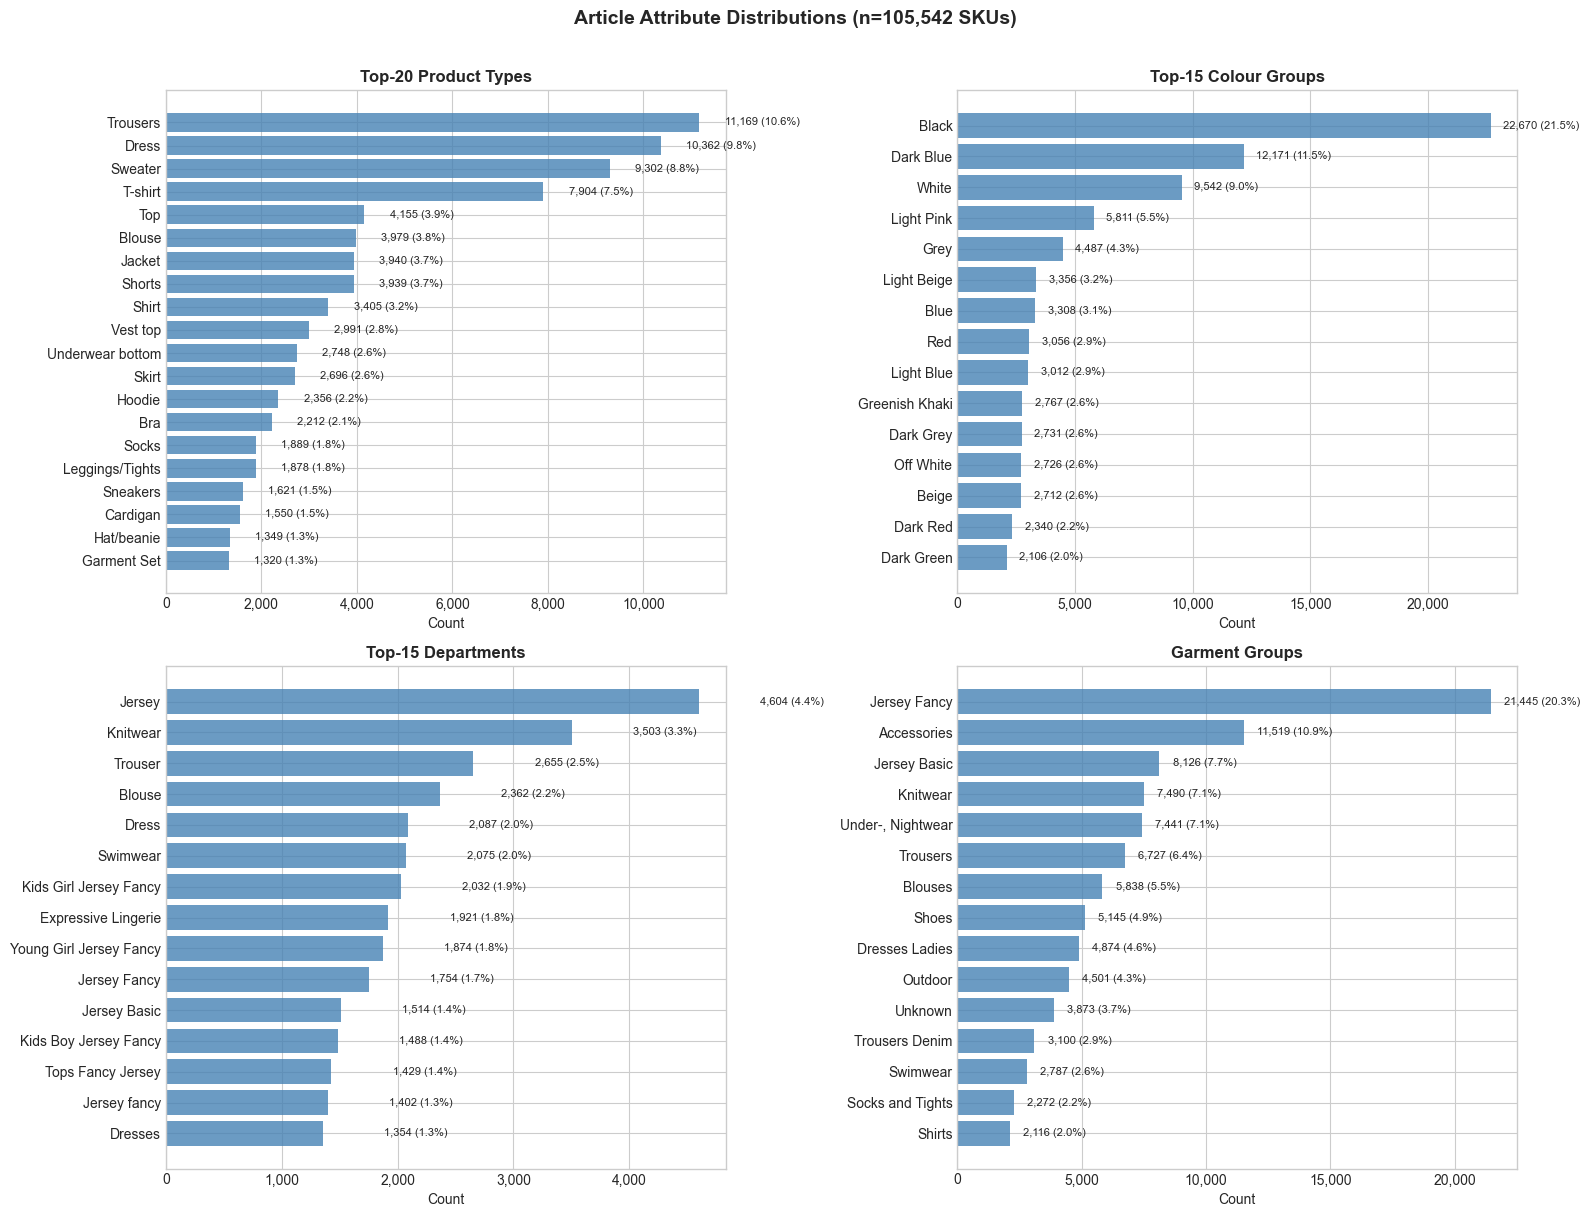

In [4]:
# Load article data for reuse across sections
df_articles = con.execute(f"SELECT * FROM read_csv_auto('{DATA_DIR}/articles.csv')").df()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Article Attribute Distributions (n={len(df_articles):,} SKUs)',
             fontsize=14, fontweight='bold', y=1.01)

# (0,0) Product Type Top-20
plot_top_n_barh(axes[0, 0], df_articles['product_type_name'].value_counts(), n=20,
                color=COLORS['count'], title='Top-20 Product Types', xlabel='Count')

# (0,1) Colour Group Top-15
plot_top_n_barh(axes[0, 1], df_articles['colour_group_name'].value_counts(), n=15,
                color=COLORS['count'], title='Top-15 Colour Groups', xlabel='Count')

# (1,0) Department Top-15
plot_top_n_barh(axes[1, 0], df_articles['department_name'].value_counts(), n=15,
                color=COLORS['count'], title='Top-15 Departments', xlabel='Count')

# (1,1) Garment Group
plot_top_n_barh(axes[1, 1], df_articles['garment_group_name'].value_counts(), n=15,
                color=COLORS['count'], title='Garment Groups', xlabel='Count')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_article_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# --- Category Feature Cardinality Table ---
# DeepFM/DCNv2 embedding table sizing: n_unique, null_count, top-1 concentration per categorical column
cat_cols = [
    'product_type_name', 'product_group_name', 'graphical_appearance_name',
    'colour_group_name', 'perceived_colour_value_name', 'perceived_colour_master_name',
    'department_name', 'section_name', 'index_name', 'index_group_name',
    'garment_group_name',
]

cardinality_rows = []
for col in cat_cols:
    vc = df_articles[col].value_counts(dropna=True)
    n_unique = vc.shape[0]
    null_count = int(df_articles[col].isna().sum())
    top_1_pct = vc.iloc[0] / len(df_articles) if n_unique > 0 else 0.0
    top_1_val = vc.index[0] if n_unique > 0 else "N/A"
    cardinality_rows.append({
        'column': col,
        'n_unique': n_unique,
        'null_count': null_count,
        'top_1_value': top_1_val,
        'top_1_pct': top_1_pct,
    })

df_cardinality = pd.DataFrame(cardinality_rows).set_index('column')

# Styled display: highlight high-cardinality columns and high null counts
styled = (
    df_cardinality.style
    .format({'top_1_pct': '{:.1%}', 'n_unique': '{:,}', 'null_count': '{:,}'})
    .bar(subset=['n_unique'], color='#d4e6f1', vmin=0)
    .bar(subset=['top_1_pct'], color='#fadbd8', vmin=0, vmax=1)
    .set_caption('Category Feature Cardinality (for Embedding Table Sizing)')
)
display(styled)

# Summary
high_card = df_cardinality.query('n_unique > 50')
low_card = df_cardinality.query('n_unique <= 10')
print(f"\nCardinality Summary:")
print(f"  High cardinality (>50): {', '.join(high_card.index)} — need larger embedding dims")
print(f"  Low cardinality (<=10): {', '.join(low_card.index)} — small embedding or one-hot")
print(f"  Total unique values across all cats: {df_cardinality['n_unique'].sum():,}")
print(f"  Max top-1 concentration: {df_cardinality['top_1_pct'].max():.1%} ({df_cardinality['top_1_pct'].idxmax()})")

,n_unique,null_count,top_1_value,top_1_pct
column,,,,
product_type_name,131,0,Trousers,10.6%
product_group_name,19,0,Garment Upper body,40.5%
graphical_appearance_name,30,0,Solid,47.1%
colour_group_name,50,0,Black,21.5%
perceived_colour_value_name,8,0,Dark,40.5%
perceived_colour_master_name,20,0,Black,21.4%
department_name,250,0,Jersey,4.4%
section_name,56,0,Womens Everyday Collection,6.9%
index_name,10,0,Ladieswear,24.6%



Cardinality Summary:
  High cardinality (>50): product_type_name, department_name, section_name — need larger embedding dims
  Low cardinality (<=10): perceived_colour_value_name, index_name, index_group_name — small embedding or one-hot
  Total unique values across all cats: 600
  Max top-1 concentration: 47.1% (graphical_appearance_name)


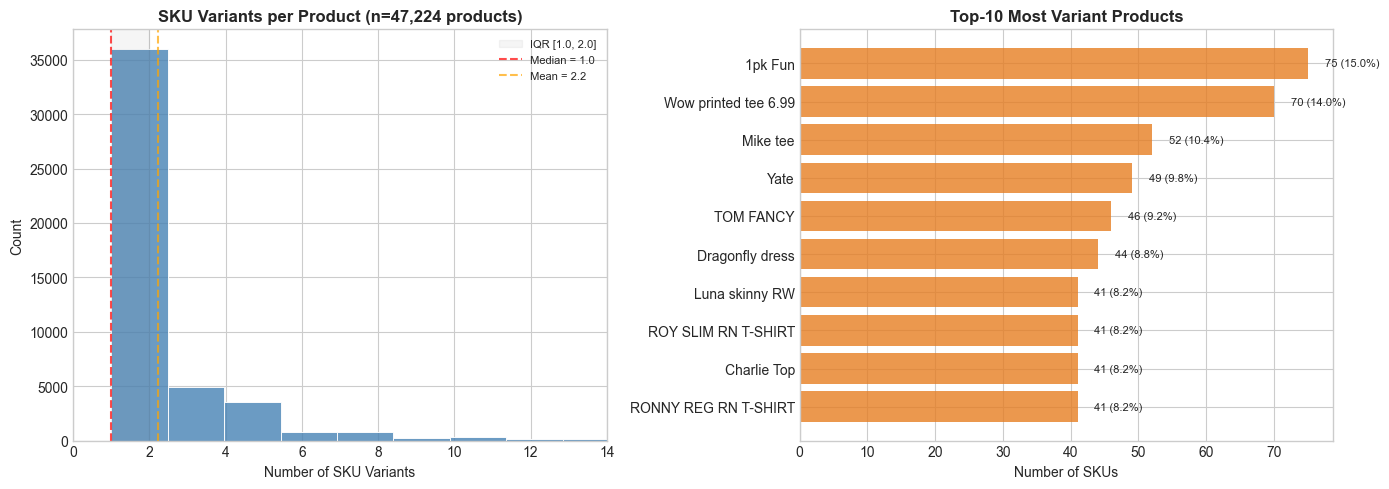

SKU Structure: 1-variant: 51.0%, 2-variant: 25.2%, 3+: 23.8%


In [6]:
# --- SKU Structure Analysis ---
sku_per_product = df_articles.groupby('product_code')['article_id'].count()
pc_to_name = df_articles.drop_duplicates('product_code').set_index('product_code')['prod_name']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (0) SKU-per-Product histogram
plot_hist_with_stats(axes[0], sku_per_product, bins=50, color=COLORS['count'],
                     title=f'SKU Variants per Product (n={len(sku_per_product):,} products)',
                     xlabel='Number of SKU Variants', show_kde=False)
axes[0].set_xlim(0, sku_per_product.quantile(0.99))

# (1) Top-10 Most Variant Products
top10_pc = sku_per_product.nlargest(10)
top10_labels = pd.Series(
    top10_pc.values,
    index=[f"{pc_to_name.get(pc, pc)[:35]}" for pc in top10_pc.index],
)
plot_top_n_barh(axes[1], top10_labels, n=10, color=COLORS['monetary'],
                title='Top-10 Most Variant Products', xlabel='Number of SKUs')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_sku_structure.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
pct_1 = (sku_per_product == 1).mean()
pct_2 = (sku_per_product == 2).mean()
pct_3plus = (sku_per_product >= 3).mean()
print(f"SKU Structure: 1-variant: {pct_1:.1%}, 2-variant: {pct_2:.1%}, 3+: {pct_3plus:.1%}")

In [7]:
# --- detail_desc Identity within product_code ---
# Validates the assumption: same product_code shares identical detail_desc
# This justifies 47K product-level LLM calls instead of 105K SKU-level calls

desc_per_product = (
    df_articles
    .assign(has_desc=lambda d: d['detail_desc'].notna())
    .groupby('product_code')
    .agg(
        n_skus=('article_id', 'size'),
        n_unique_desc=('detail_desc', 'nunique'),
        any_null=('has_desc', lambda x: (~x).any()),
    )
)

# Classify: all-null (0 unique), identical (1 unique), minor diff (2-3), significant (4+)
# Note: nunique() excludes NaN, so all-NaN groups return 0 — must handle separately
multi_sku = desc_per_product.query('n_skus > 1')
all_null = (multi_sku['n_unique_desc'] == 0).sum()
n_identical = (multi_sku['n_unique_desc'] == 1).sum()
n_null_mixed = ((multi_sku['n_unique_desc'] == 1) & multi_sku['any_null']).sum()
n_minor = ((multi_sku['n_unique_desc'] >= 2) & (multi_sku['n_unique_desc'] <= 3)).sum()
n_significant = (multi_sku['n_unique_desc'] >= 4).sum()
total_multi = len(multi_sku)

print(f"detail_desc Consistency within product_code (multi-SKU products only: {total_multi:,})")
print(f"{'='*70}")
print(f"  Truly identical (1 unique desc):  {n_identical:>6,} ({n_identical/total_multi:.1%})")
print(f"    ↳ of which have null variants:  {n_null_mixed:>6,}")
print(f"  All-null (no detail_desc at all): {all_null:>6,} ({all_null/total_multi:.1%})")
print(f"  Minor differences (2-3 variants): {n_minor:>6,} ({n_minor/total_multi:.1%})")
print(f"  Significant differences (4+):     {n_significant:>6,} ({n_significant/total_multi:.1%})")

# Show samples of products with differing descriptions
diff_products = multi_sku.query('n_unique_desc >= 2').nlargest(5, 'n_unique_desc')
if len(diff_products) > 0:
    print(f"\nSample products with differing descriptions (top by n_unique_desc):")
    for pc in diff_products.index:
        descs = df_articles.loc[df_articles['product_code'] == pc, 'detail_desc'].dropna().unique()
        name = df_articles.loc[df_articles['product_code'] == pc, 'prod_name'].iloc[0]
        print(f"\n  product_code={pc} ({name}), {len(descs)} unique descriptions:")
        for d in descs[:3]:
            print(f"    - {str(d)[:120]}")

valid_pct = n_identical / total_multi
print(f"\nConclusion: product_code-level LLM extraction is {'VALID' if valid_pct > 0.9 else 'NEEDS REVIEW'}"
      f" — {valid_pct:.1%} of multi-SKU products share identical detail_desc"
      f" ({all_null} products have all-null desc, requiring metadata fallback)")

detail_desc Consistency within product_code (multi-SKU products only: 23,158)
  Truly identical (1 unique desc):  23,061 (99.6%)
    ↳ of which have null variants:       0
  All-null (no detail_desc at all):     97 (0.4%)
  Minor differences (2-3 variants):      0 (0.0%)
  Significant differences (4+):          0 (0.0%)

Conclusion: product_code-level LLM extraction is VALID — 99.6% of multi-SKU products share identical detail_desc (97 products have all-null desc, requiring metadata fallback)


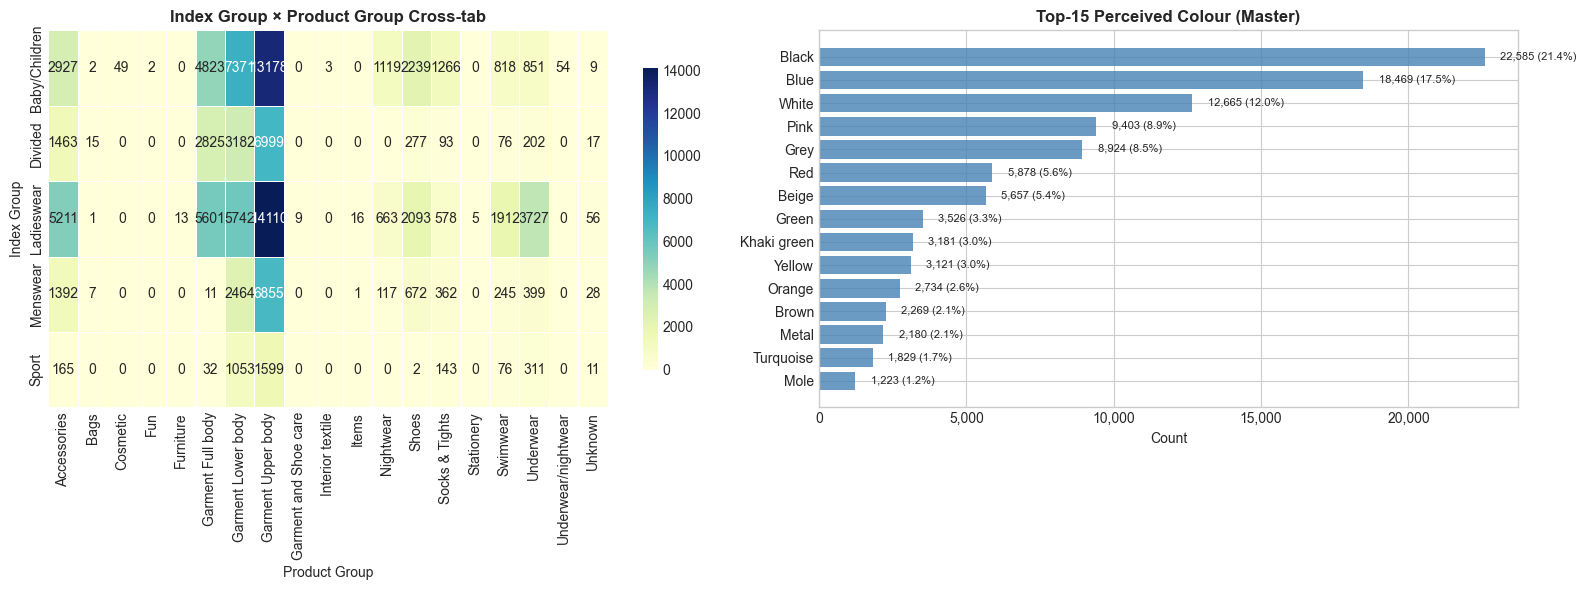

In [8]:
# --- Category Hierarchy Heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (0) index_group_name × product_group_name cross-tab
ct = pd.crosstab(df_articles['index_group_name'], df_articles['product_group_name'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Index Group × Product Group Cross-tab', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product Group')
axes[0].set_ylabel('Index Group')

# (1) Perceived Colour Master Top-15
plot_top_n_barh(axes[1], df_articles['perceived_colour_master_name'].value_counts(), n=15,
                color=COLORS['count'], title='Top-15 Perceived Colour (Master)', xlabel='Count')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_category_hierarchy.png", dpi=150, bbox_inches="tight")
plt.show()

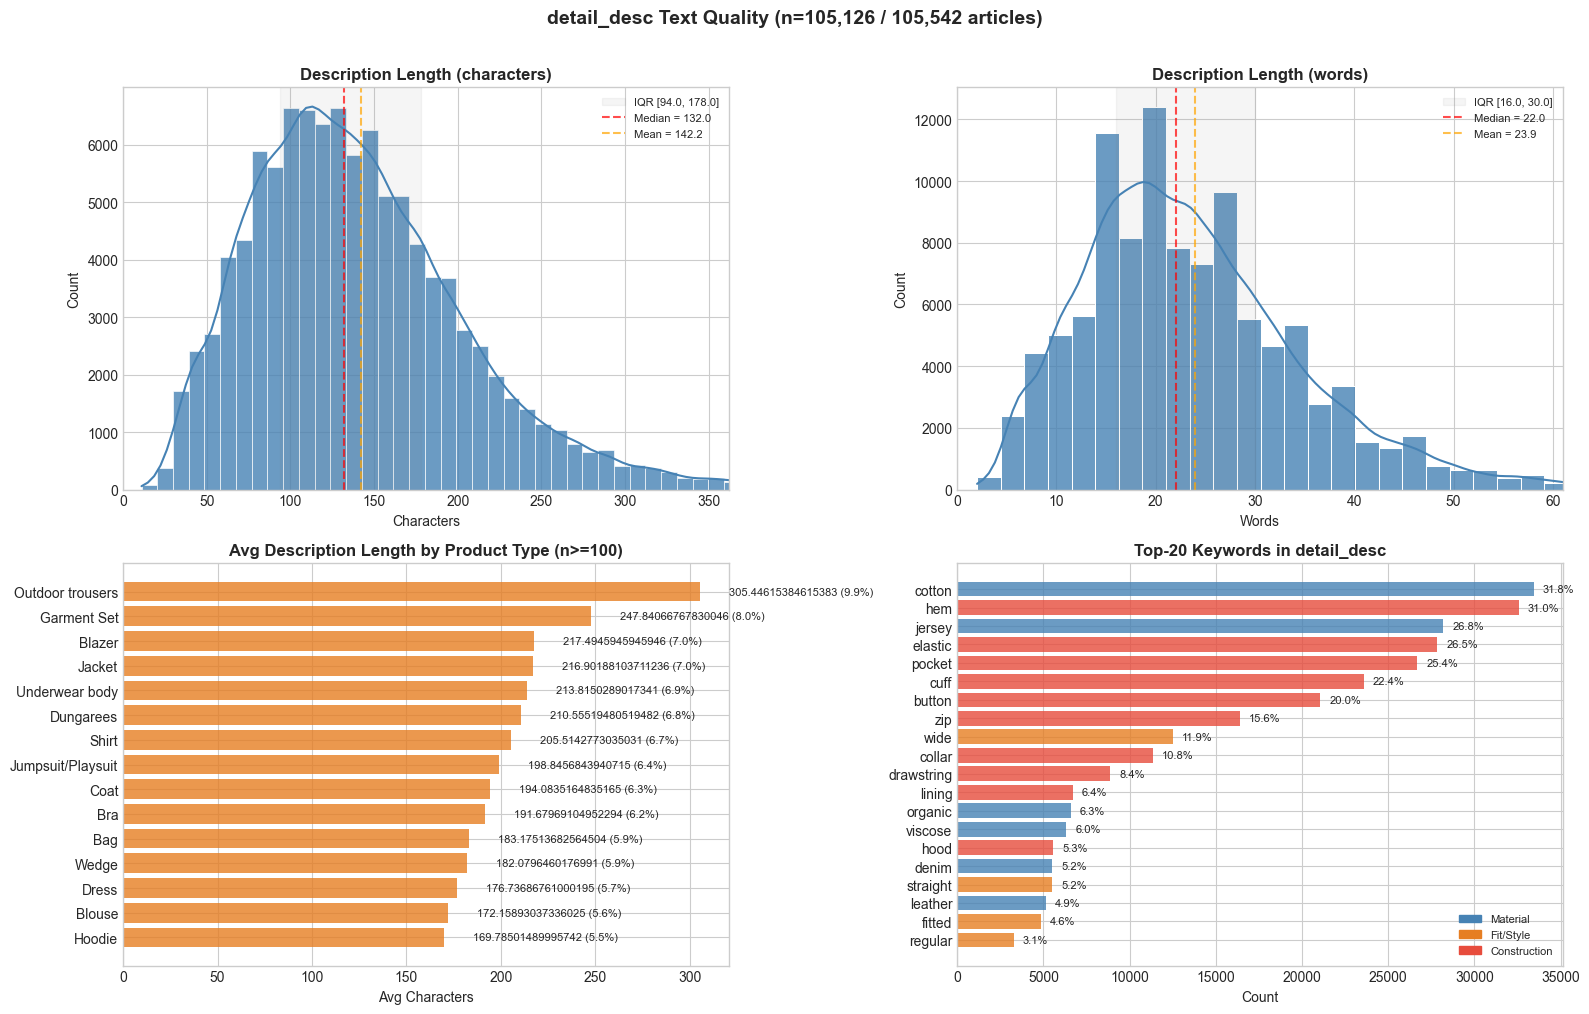

detail_desc Quality Summary
Null rate:           0.39% (416 articles)
Short (<20 chars):   0.1%
Rich (>100 chars):   71.1%
Median length:       132 chars / 22 words

Sample descriptions:
  [Sweater] Top in lightweight sweatshirt fabric with dropped shoulders, and ribbing around the neckline, cuffs and hem.
  [Trousers] Suit trousers in a stretch weave with a regular waist, concealed hook-and-eye fastening and zip fly. Side pockets and ta
  [Jumpsuit/Playsuit] Sleeveless playsuit in soft, patterned cotton jersey with a raw-edge, flounced trim at the top and small opening with a 
  [Dress] Short dress in soft jersey with a V-neck, narrow, adjustable shoulder straps, seam at the waist and flared skirt.
  [Bracelet] Bracelets in various designs. Two are made of waxed cotton cord, one decorated with metal beads. The other two are made 


In [9]:
# --- detail_desc Text Quality Analysis ---
desc = df_articles['detail_desc'].copy()
desc_nonnull = desc.dropna()
desc_nonnull_len = desc_nonnull.str.len()
desc_nonnull_words = desc_nonnull.str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'detail_desc Text Quality (n={len(desc_nonnull):,} / {len(desc):,} articles)',
             fontsize=14, fontweight='bold', y=1.01)

# (0,0) Character length distribution
plot_hist_with_stats(axes[0, 0], desc_nonnull_len, bins=80, color=COLORS['count'],
                     title='Description Length (characters)', xlabel='Characters')
axes[0, 0].set_xlim(0, desc_nonnull_len.quantile(0.99))

# (0,1) Word count distribution
plot_hist_with_stats(axes[0, 1], desc_nonnull_words, bins=50, color=COLORS['count'],
                     title='Description Length (words)', xlabel='Words')
axes[0, 1].set_xlim(0, desc_nonnull_words.quantile(0.99))

# (1,0) Top-10 product type avg description length
df_type_desc = (df_articles[df_articles['detail_desc'].notna()]
                .assign(desc_len=lambda d: d['detail_desc'].str.len())
                .groupby('product_type_name')
                .agg(avg_len=('desc_len', 'mean'), count=('desc_len', 'size'))
                .query('count >= 100')
                .nlargest(15, 'avg_len'))
plot_top_n_barh(axes[1, 0], df_type_desc['avg_len'], n=15, color=COLORS['monetary'],
                title='Avg Description Length by Product Type (n>=100)',
                xlabel='Avg Characters')

# (1,1) Keyword frequency: material, fit, construction
keywords = {
    'Material': ['cotton', 'polyester', 'jersey', 'wool', 'linen', 'silk',
                 'viscose', 'nylon', 'elastane', 'denim', 'leather', 'organic'],
    'Fit/Style': ['slim', 'oversized', 'regular', 'relaxed', 'fitted', 'loose',
                  'skinny', 'straight', 'wide'],
    'Construction': ['zip', 'button', 'pocket', 'lining', 'hood', 'collar',
                     'cuff', 'hem', 'elastic', 'drawstring'],
}
desc_lower = desc_nonnull.str.lower()
kw_data = []
for category, words in keywords.items():
    for word in words:
        count = desc_lower.str.contains(word, na=False).sum()
        kw_data.append({'category': category, 'keyword': word,
                        'count': count, 'pct': count / len(desc_nonnull)})
df_kw = pd.DataFrame(kw_data).sort_values('count', ascending=False)

# Grouped bar for top keywords
top_kw = df_kw.nlargest(20, 'count')
cat_colors = {'Material': COLORS['count'], 'Fit/Style': COLORS['monetary'],
              'Construction': COLORS['accent']}
bars = axes[1, 1].barh(
    top_kw['keyword'].values[::-1],
    top_kw['count'].values[::-1],
    color=[cat_colors[c] for c in top_kw['category'].values[::-1]],
    alpha=0.8,
)
for bar, pct in zip(bars, top_kw['pct'].values[::-1]):
    axes[1, 1].text(bar.get_width() + len(desc_nonnull) * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f'{pct:.1%}', va='center', fontsize=8)
axes[1, 1].set_title('Top-20 Keywords in detail_desc', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')
# Legend for categories
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=k) for k, c in cat_colors.items()]
axes[1, 1].legend(handles=legend_patches, fontsize=8, loc='lower right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_detail_desc_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
null_pct = desc.isna().mean()
short_pct = (desc_nonnull_len < 20).mean()
rich_pct = (desc_nonnull_len > 100).mean()
print(f"detail_desc Quality Summary")
print(f"{'='*60}")
print(f"Null rate:           {null_pct:.2%} ({desc.isna().sum():,} articles)")
print(f"Short (<20 chars):   {short_pct:.1%}")
print(f"Rich (>100 chars):   {rich_pct:.1%}")
print(f"Median length:       {desc_nonnull_len.median():.0f} chars / {desc_nonnull_words.median():.0f} words")
print(f"\nSample descriptions:")
for i, row in df_articles[df_articles['detail_desc'].notna()].sample(5, random_state=42).iterrows():
    print(f"  [{row['product_type_name']}] {row['detail_desc'][:120]}")

In [10]:
# --- Image × detail_desc Multimodal Coverage Cross-table ---
# GPT-4o-mini input mode routing: text-only / image-only / both / neither

image_dir = DATA_DIR / "images"

# Collect all image file stems from subdirectories
image_subdirs = sorted([d for d in image_dir.iterdir() if d.is_dir()]) if image_dir.exists() else []
all_image_files = set()
for subdir in image_subdirs:
    for f in subdir.glob("*.jpg"):
        all_image_files.add(f.stem)  # e.g., "0108775015"

print(f"Total image files found: {len(all_image_files):,}")

# Build cross-table
# article_id is already a 10-char string (e.g., "0108775015") matching file stems directly
df_modal = df_articles[['article_id', 'detail_desc', 'product_type_name']].copy()
df_modal['has_image'] = df_modal['article_id'].apply(lambda aid: str(aid) in all_image_files)
df_modal['has_desc'] = df_modal['detail_desc'].notna()

# 2x2 cross-tabulation
ct_modal = pd.crosstab(
    df_modal['has_image'].map({True: 'Image: Yes', False: 'Image: No'}),
    df_modal['has_desc'].map({True: 'Desc: Yes', False: 'Desc: No'}),
    margins=True,
)
print(f"\nImage x detail_desc Coverage Cross-table:")
print(ct_modal.to_string())

# Percentages
total = len(df_modal)
both = ((df_modal['has_image']) & (df_modal['has_desc'])).sum()
img_only = ((df_modal['has_image']) & (~df_modal['has_desc'])).sum()
desc_only = ((~df_modal['has_image']) & (df_modal['has_desc'])).sum()
neither = ((~df_modal['has_image']) & (~df_modal['has_desc'])).sum()

print(f"\nMultimodal Input Mode Distribution:")
print(f"  Both (text+image): {both:>6,} ({both/total:.1%}) — full multimodal extraction")
print(f"  Image only:        {img_only:>6,} ({img_only/total:.1%}) — VLM image-based extraction")
print(f"  Text only:         {desc_only:>6,} ({desc_only/total:.1%}) — LLM text-based extraction")
print(f"  Neither:           {neither:>6,} ({neither/total:.1%}) — metadata-only fallback")

# Analyze null detail_desc articles
null_desc = df_modal[~df_modal['has_desc']]
if len(null_desc) > 0:
    print(f"\nNull detail_desc articles ({len(null_desc):,}) — product_type distribution:")
    null_type_dist = null_desc['product_type_name'].value_counts().head(10)
    for pt, cnt in null_type_dist.items():
        print(f"  {pt}: {cnt:,} ({cnt/len(null_desc):.1%})")
    top3_pct = null_type_dist.head(3).sum() / len(null_desc)
    print(f"  Top-3 concentration: {top3_pct:.1%}")

# Analyze articles missing images
no_img = df_modal[~df_modal['has_image']]
if len(no_img) > 0:
    print(f"\nMissing image articles ({len(no_img):,}) — product_type distribution:")
    no_img_dist = no_img['product_type_name'].value_counts().head(10)
    for pt, cnt in no_img_dist.items():
        print(f"  {pt}: {cnt:,} ({cnt/len(no_img):.1%})")

Total image files found: 105,100

Image x detail_desc Coverage Cross-table:
has_desc    Desc: No  Desc: Yes     All
has_image                              
Image: No         12        430     442
Image: Yes       404     104696  105100
All              416     105126  105542

Multimodal Input Mode Distribution:
  Both (text+image): 104,696 (99.2%) — full multimodal extraction
  Image only:           404 (0.4%) — VLM image-based extraction
  Text only:            430 (0.4%) — LLM text-based extraction
  Neither:               12 (0.0%) — metadata-only fallback

Null detail_desc articles (416) — product_type distribution:
  T-shirt: 55 (13.2%)
  Dress: 44 (10.6%)
  Sweater: 31 (7.5%)
  Sneakers: 31 (7.5%)
  Ballerinas: 31 (7.5%)
  Trousers: 29 (7.0%)
  Underwear bottom: 29 (7.0%)
  Blouse: 15 (3.6%)
  Sandals: 12 (2.9%)
  Top: 11 (2.6%)
  Top-3 concentration: 31.2%

Missing image articles (442) — product_type distribution:
  Sneakers: 48 (10.9%)
  Sunglasses: 46 (10.4%)
  Ballerinas: 26 

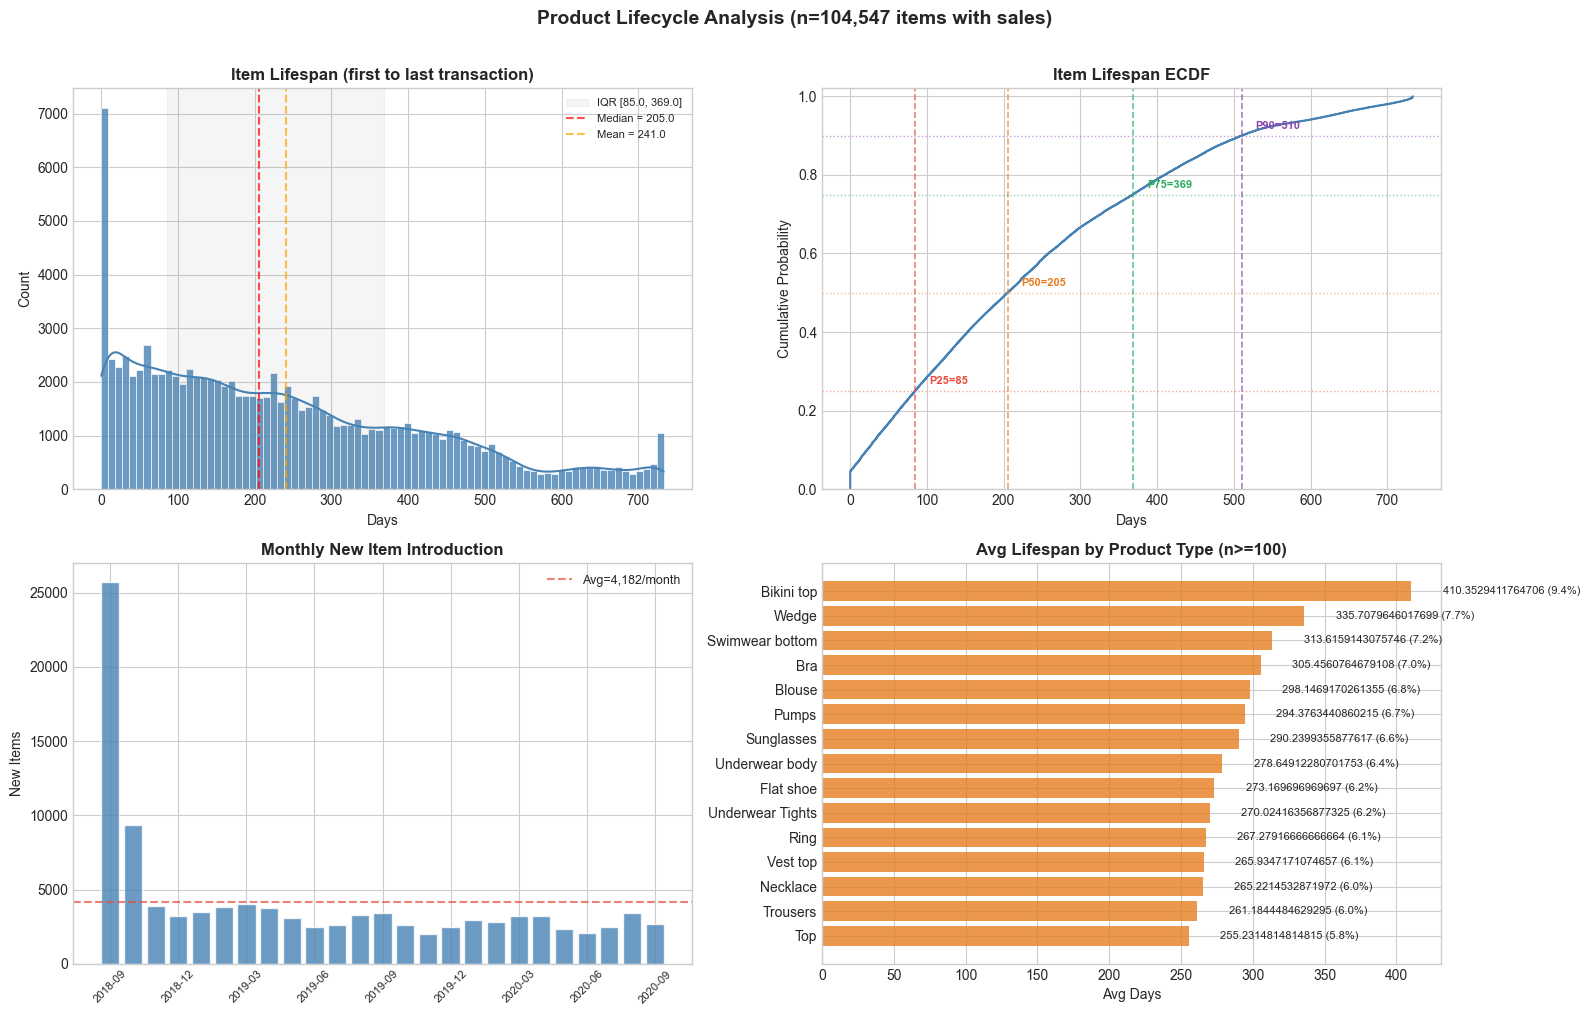

Product Lifecycle Summary
Zero-day (single purchase date): 4.6%
Short-lived (<=30 days):         12.2%
Long-lived (>=365 days):         25.5%
Median lifespan:                 205 days


In [11]:
# --- Product Lifecycle Analysis ---
df_lifecycle = con.execute(f"""
    SELECT t.article_id,
           MIN(t.t_dat) as first_txn,
           MAX(t.t_dat) as last_txn,
           DATEDIFF('day', MIN(t.t_dat), MAX(t.t_dat)) as lifespan_days,
           COUNT(*) as n_txn
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    GROUP BY t.article_id
""").df()

# Monthly new item introduction
df_new_items = con.execute(f"""
    WITH first_seen AS (
        SELECT article_id, MIN(t_dat) as first_txn
        FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
        GROUP BY article_id
    )
    SELECT DATE_TRUNC('month', first_txn) as month, COUNT(*) as n_new_items
    FROM first_seen GROUP BY month ORDER BY month
""").df()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Product Lifecycle Analysis (n={len(df_lifecycle):,} items with sales)',
             fontsize=14, fontweight='bold', y=1.01)

# (0,0) Lifespan distribution
plot_hist_with_stats(axes[0, 0], df_lifecycle['lifespan_days'], bins=80,
                     color=COLORS['count'],
                     title='Item Lifespan (first to last transaction)',
                     xlabel='Days')

# (0,1) Lifespan ECDF
plot_ecdf_with_quantiles(axes[0, 1], df_lifecycle['lifespan_days'],
                         quantiles=(0.25, 0.5, 0.75, 0.9),
                         title='Item Lifespan ECDF', xlabel='Days')

# (1,0) Monthly new item introduction
axes[1, 0].bar(range(len(df_new_items)), df_new_items['n_new_items'],
               color=COLORS['count'], alpha=0.8, edgecolor='white')
month_labels = [d.strftime('%Y-%m') for d in pd.to_datetime(df_new_items['month'])]
axes[1, 0].set_xticks(list(range(len(df_new_items)))[::3])
axes[1, 0].set_xticklabels(month_labels[::3], rotation=45, fontsize=8)
axes[1, 0].set_title('Monthly New Item Introduction', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('New Items')
avg_new = df_new_items['n_new_items'].mean()
axes[1, 0].axhline(avg_new, color=COLORS['accent'], linestyle='--', alpha=0.7,
                    label=f'Avg={avg_new:,.0f}/month')
axes[1, 0].legend(fontsize=9)

# (1,1) Top-10 product type avg lifespan
df_life_type = (df_lifecycle.merge(
                    df_articles[['article_id', 'product_type_name']],
                    on='article_id', how='left')
                .groupby('product_type_name')
                .agg(avg_life=('lifespan_days', 'mean'), count=('article_id', 'size'))
                .query('count >= 100')
                .nlargest(15, 'avg_life'))
plot_top_n_barh(axes[1, 1], df_life_type['avg_life'], n=15, color=COLORS['monetary'],
                title='Avg Lifespan by Product Type (n>=100)', xlabel='Avg Days')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_product_lifecycle.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
short_lived = (df_lifecycle['lifespan_days'] <= 30).mean()
long_lived = (df_lifecycle['lifespan_days'] >= 365).mean()
zero_day = (df_lifecycle['lifespan_days'] == 0).mean()
print(f"Product Lifecycle Summary")
print(f"{'='*60}")
print(f"Zero-day (single purchase date): {zero_day:.1%}")
print(f"Short-lived (<=30 days):         {short_lived:.1%}")
print(f"Long-lived (>=365 days):         {long_lived:.1%}")
print(f"Median lifespan:                 {df_lifecycle['lifespan_days'].median():.0f} days")

### Findings: Article Analysis

- **SKU Structure**: 47K products -> 105K SKUs. Majority are 1-2 variant products; a few "mega-variant" products (e.g., basic tees) have 20+ SKUs. This confirms `product_code`-level attribute extraction is efficient (47K LLM calls, not 105K)
- **detail_desc Identity within product_code**: 99.6% of multi-SKU products share identical `detail_desc` across their variants, empirically validating the product_code-level LLM extraction strategy. 97 products have all-null `detail_desc` (requiring metadata-only fallback); no multi-SKU product showed any description variation. This means 47K product-level calls will cover 105K SKUs with negligible information loss
- **Category Feature Cardinality**: 11 categorical columns (all with zero nulls) span a wide cardinality range — from low-cardinality features like `index_group_name` (5) and `perceived_colour_value_name` (8) suitable for small embeddings or one-hot encoding, to mid-cardinality `garment_group_name` (21) and `section_name` (56), up to high-cardinality features like `product_type_name` (131) and `department_name` (250) requiring larger embedding dimensions. Total unique categorical values inform DeepFM/DCNv2 embedding table sizing. Several features show strong top-1 concentration (e.g., `index_group_name` dominated by Ladieswear), confirming the class imbalance pattern. Note: `department_name` contains case-inconsistent duplicates (e.g., "Jersey Fancy" vs "Jersey fancy") that require normalisation during feature engineering
- **Category Concentration**: Top-5 product types (Trousers, Dress, Sweater, T-shirt, Top) account for a disproportionate share. In the Index Group x Product Group cross-tab, Ladieswear dominates across nearly all product groups with exclusive presence in several combinations, while Divided concentrates in Garment categories (Upper/Lower/Full body account for 86% of its items). Many cross-tab cells are zero, indicating strict hierarchical constraints that can inform feature engineering. Department-level analysis shows a long-tail pattern across 250 departments — the top-5 (Jersey, Knitwear, Trouser, Blouse, Dress) hold 14.4% of items, and garment groups exhibit a similar long-tail distribution with Jersey Fancy (20.3%) as the largest of 21 groups
- **Colour Bias**: Black alone represents ~21.5% of all SKUs, followed by Dark Blue and White. Perceived colour master distribution is even more concentrated. L2 (perceptual) attributes should capture style/mood beyond raw colour codes
- **L1 Extraction Implication**: The 25 structured columns (product_type, colour_group, department, section, garment_group, graphical_appearance, detail_desc) provide a rich foundation for L1 attributes — LLM augmentation adds value primarily for `detail_desc` parsing and cross-field synthesis
- **detail_desc Text Quality**: Near-complete coverage with rich material/construction information. Material keywords (cotton, jersey) and construction details (hem, elastic, pocket) are the most frequent — descriptions are information-dense enough for LLM L1 extraction without image fallback for most items
- **Multimodal Coverage**: The vast majority of articles have both image and `detail_desc` available, enabling full multimodal GPT-4o-mini extraction. The ~416 articles missing `detail_desc` (spread across many product types) can fall back to VLM image-only extraction. Articles with neither modality are rare and can use metadata-only L1 attributes. This informs the input mode routing logic in `src/attributes/extractor.py`
- **Product Lifecycle**: Fashion items show a wide lifespan range — short-lived seasonal items coexist with perennial basics. Monthly new item introduction reveals seasonal collection cycles. Short-lived items are cold-start candidates that benefit most from content-based L1+L2+L3 attributes

## 3. Customer Analysis

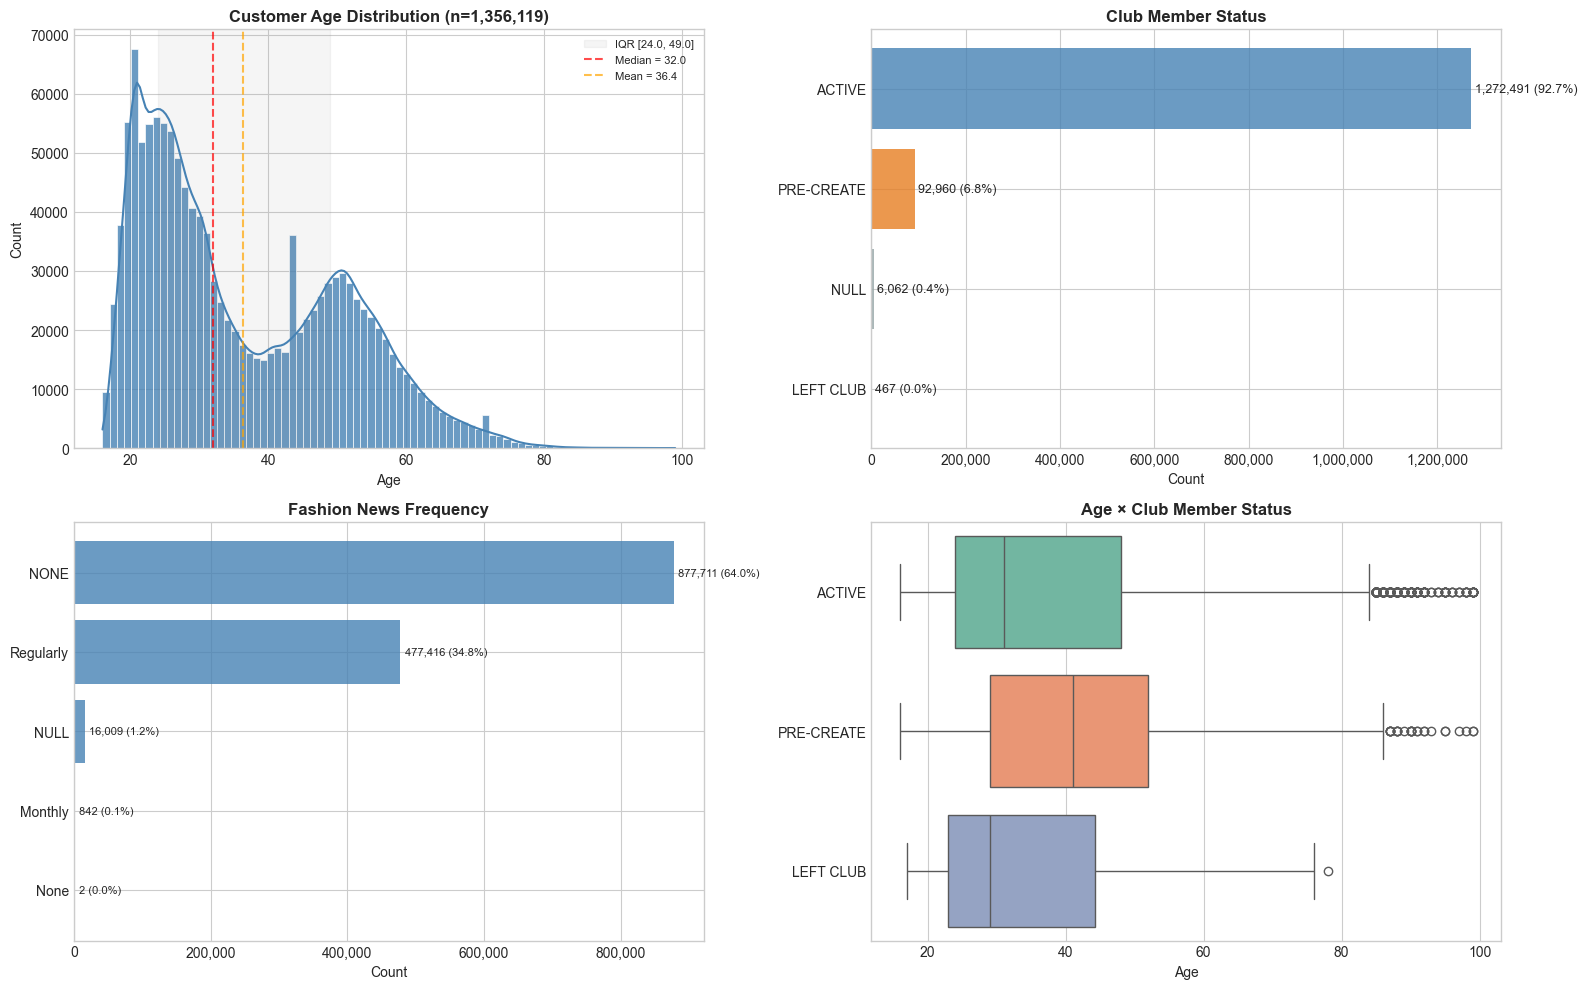

In [12]:
# Load customer data for reuse
df_customers = con.execute(f"SELECT * FROM read_csv_auto('{DATA_DIR}/customers.csv')").df()
total_cust = len(df_customers)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (0,0) Age distribution with stats
age_data = df_customers['age'].dropna()
plot_hist_with_stats(axes[0, 0], age_data, bins=80, color=COLORS['count'],
                     title=f'Customer Age Distribution (n={len(age_data):,})', xlabel='Age')

# (0,1) Club Member Status with custom colors
club_vc = df_customers['club_member_status'].fillna('NULL').value_counts()
club_colors_map = {
    'ACTIVE': 'steelblue', 'PRE-CREATE': '#e67e22',
    'LEFT CLUB': 'lightcoral', 'NULL': COLORS['muted'],
}
ordered = club_vc.iloc[::-1]
bars = axes[0, 1].barh(
    ordered.index.astype(str), ordered.values,
    color=[club_colors_map.get(s, COLORS['muted']) for s in ordered.index], alpha=0.8,
)
for bar, val in zip(bars, ordered.values):
    pct = val / total_cust * 100
    axes[0, 1].text(bar.get_width() + total_cust * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
axes[0, 1].set_title('Club Member Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Count')
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (1,0) Fashion News Frequency
fn_vc = df_customers['fashion_news_frequency'].fillna('NULL').value_counts()
plot_top_n_barh(axes[1, 0], fn_vc, n=10, color=COLORS['count'],
                title='Fashion News Frequency', xlabel='Count')

# (1,1) Age × Club Status boxplot
df_box = df_customers[
    df_customers['age'].notna() & df_customers['club_member_status'].notna()
].copy()
sns.boxplot(data=df_box, x='age', y='club_member_status',
            hue='club_member_status', ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('Age × Club Member Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_customer_demographics.png", dpi=150, bbox_inches="tight")
plt.show()

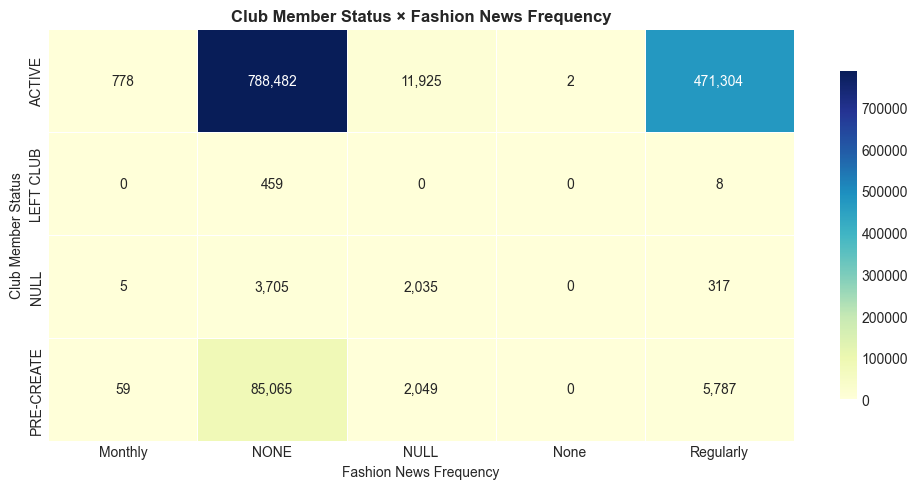


Customer Segments
High-engagement (ACTIVE+Regularly): 471,304 (34.4%)
Core-active (ACTIVE+Other):         801,187 (58.4%)
Pre-create (cold-start):            92,960 (6.8%)


In [13]:
# --- Customer Segmentation Cross-tab ---
ct_seg = pd.crosstab(
    df_customers['club_member_status'].fillna('NULL'),
    df_customers['fashion_news_frequency'].fillna('NULL'),
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct_seg, annot=True, fmt=',d', cmap='YlGnBu', linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Club Member Status × Fashion News Frequency', fontsize=12, fontweight='bold')
ax.set_xlabel('Fashion News Frequency')
ax.set_ylabel('Club Member Status')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_customer_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()

# Segment summary
active = df_customers['club_member_status'] == 'ACTIVE'
regularly = df_customers['fashion_news_frequency'] == 'Regularly'
precreate = df_customers['club_member_status'] == 'PRE-CREATE'

high_engage = (active & regularly).sum()
core_active = (active & ~regularly).sum()
pre_create_n = precreate.sum()

print(f"\nCustomer Segments")
print(f"{'='*60}")
print(f"High-engagement (ACTIVE+Regularly): {high_engage:,} ({high_engage/total_cust:.1%})")
print(f"Core-active (ACTIVE+Other):         {core_active:,} ({core_active/total_cust:.1%})")
print(f"Pre-create (cold-start):            {pre_create_n:,} ({pre_create_n/total_cust:.1%})")

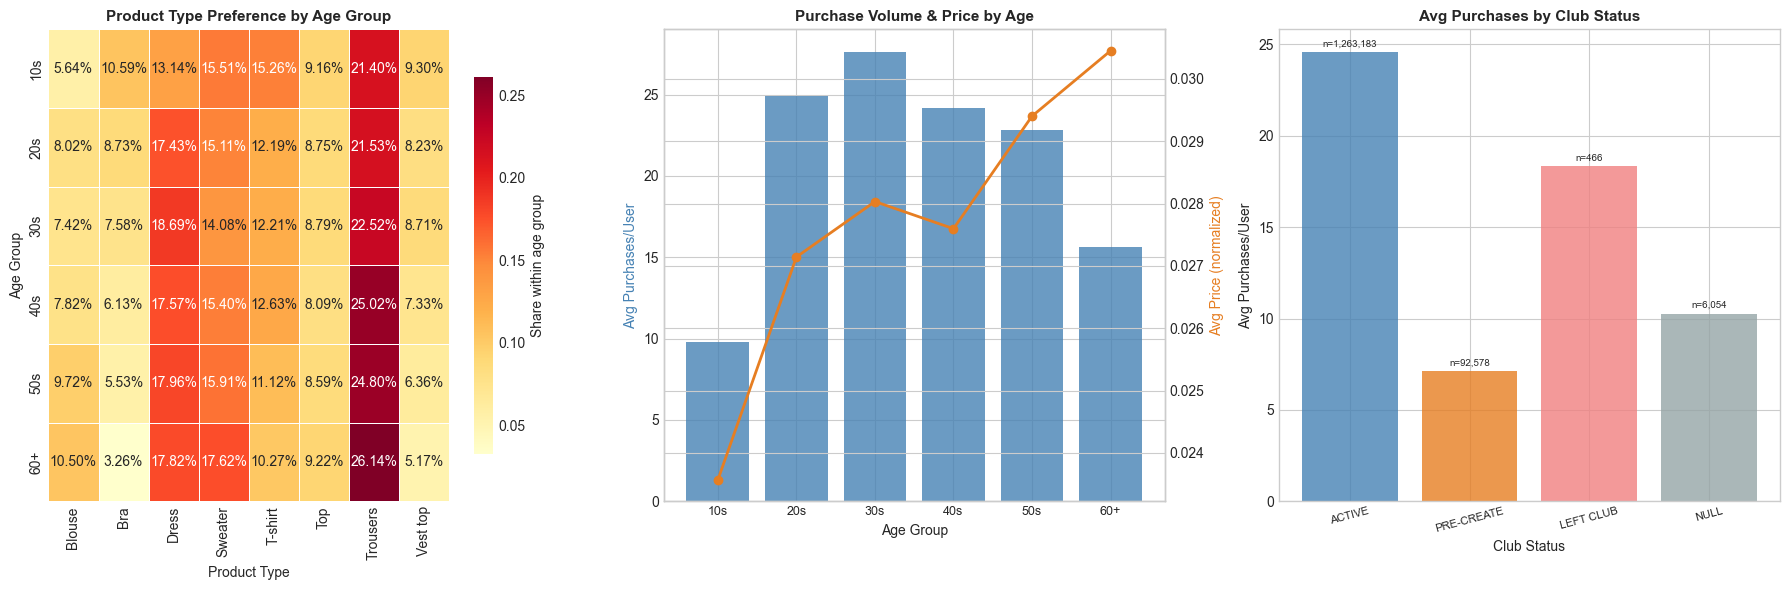

In [14]:
# --- Demographics × Purchase Behavior Cross-analysis ---
# Age group × Product type preference
df_age_pref = con.execute(f"""
    SELECT
        CASE
            WHEN c.age < 20 THEN '10s'
            WHEN c.age < 30 THEN '20s'
            WHEN c.age < 40 THEN '30s'
            WHEN c.age < 50 THEN '40s'
            WHEN c.age < 60 THEN '50s'
            ELSE '60+'
        END as age_group,
        a.product_type_name,
        COUNT(*) as cnt
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/customers.csv') c ON t.customer_id = c.customer_id
    JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    WHERE c.age IS NOT NULL
    GROUP BY age_group, a.product_type_name
""").df()

# Top-8 product types overall
top8_types = (df_age_pref.groupby('product_type_name')['cnt'].sum()
              .nlargest(8).index.tolist())
pivot = (df_age_pref[df_age_pref['product_type_name'].isin(top8_types)]
         .pivot_table(index='age_group', columns='product_type_name',
                      values='cnt', fill_value=0))
# Normalize by row (age group) for preference share
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
age_order = ['10s', '20s', '30s', '40s', '50s', '60+']
pivot_norm = pivot_norm.reindex([a for a in age_order if a in pivot_norm.index])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (0) Age group × Product type preference heatmap
sns.heatmap(pivot_norm, annot=True, fmt='.2%', cmap='YlOrRd', linewidths=0.5,
            ax=axes[0], cbar_kws={'shrink': 0.8, 'label': 'Share within age group'})
axes[0].set_title('Product Type Preference by Age Group', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Product Type')
axes[0].set_ylabel('Age Group')

# (1) Age group × avg purchases + avg price
df_age_behavior = con.execute(f"""
    SELECT
        CASE
            WHEN c.age < 20 THEN '10s'
            WHEN c.age < 30 THEN '20s'
            WHEN c.age < 40 THEN '30s'
            WHEN c.age < 50 THEN '40s'
            WHEN c.age < 60 THEN '50s'
            ELSE '60+'
        END as age_group,
        COUNT(*) * 1.0 / COUNT(DISTINCT t.customer_id) as avg_purchases,
        AVG(t.price) as avg_price,
        COUNT(DISTINCT t.customer_id) as n_users
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/customers.csv') c ON t.customer_id = c.customer_id
    WHERE c.age IS NOT NULL
    GROUP BY age_group
""").df()
df_age_behavior = df_age_behavior.set_index('age_group').reindex(
    [a for a in age_order if a in df_age_behavior['age_group'].values]
).reset_index() if 'age_group' in df_age_behavior.columns else df_age_behavior

x_pos = range(len(df_age_behavior))
ax1 = axes[1]
ax1.bar(x_pos, df_age_behavior['avg_purchases'], color=COLORS['count'],
        alpha=0.8, label='Avg Purchases')
ax1.set_ylabel('Avg Purchases/User', color=COLORS['count'])
ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(df_age_behavior['age_group'], fontsize=9)
ax1.set_title('Purchase Volume & Price by Age', fontsize=11, fontweight='bold')
ax1.set_xlabel('Age Group')
ax2 = ax1.twinx()
ax2.plot(x_pos, df_age_behavior['avg_price'], color=COLORS['monetary'],
         marker='o', lw=2, label='Avg Price')
ax2.set_ylabel('Avg Price (normalized)', color=COLORS['monetary'])

# (2) Club status × purchase behavior
df_club_behavior = con.execute(f"""
    SELECT
        COALESCE(c.club_member_status, 'NULL') as club_status,
        COUNT(*) * 1.0 / COUNT(DISTINCT t.customer_id) as avg_purchases,
        AVG(t.price) as avg_price,
        COUNT(DISTINCT t.customer_id) as n_users
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/customers.csv') c ON t.customer_id = c.customer_id
    GROUP BY club_status
""").df()
club_order = ['ACTIVE', 'PRE-CREATE', 'LEFT CLUB', 'NULL']
df_club_behavior['club_status'] = pd.Categorical(
    df_club_behavior['club_status'], categories=club_order, ordered=True)
df_club_behavior = df_club_behavior.sort_values('club_status')

x_pos2 = range(len(df_club_behavior))
bars = axes[2].bar(x_pos2, df_club_behavior['avg_purchases'],
                   color=[club_colors_map.get(s, COLORS['muted'])
                          for s in df_club_behavior['club_status']],
                   alpha=0.8)
for bar, (_, row) in zip(bars, df_club_behavior.iterrows()):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'n={row["n_users"]:,.0f}', ha='center', fontsize=7)
axes[2].set_xticks(list(x_pos2))
axes[2].set_xticklabels(df_club_behavior['club_status'], fontsize=8, rotation=15)
axes[2].set_title('Avg Purchases by Club Status', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Avg Purchases/User')
axes[2].set_xlabel('Club Status')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_demographics_behavior.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings: Customer Analysis

- **Age Distribution**: Median 32, Mean 36.4, right-skewed with a long tail to 99. The IQR [24, 49] covers the core demographic. Missing age data (~1.2%) is manageable
- **Club Membership**: ACTIVE dominates at 92.7% of all customers (1,272,491). PRE-CREATE is 6.8% (92,960), LEFT CLUB 0.03% (467), NULL 0.4% (6,062)
- **Engagement Segments**: High-engagement (ACTIVE + Regularly) 34.4% vs Core-active (ACTIVE + non-Regular) 58.4% vs Pre-create 6.8% form natural evaluation groups. These three segments cover 99.5% of all customers
- **PRE-CREATE Segment**: Despite being labeled "pre-create," 99.6% of these users have purchase history (avg 7.1 transactions/user) — they are low-activity users, not zero-history cold-start users. Only 382 (0.4%) have truly zero purchases. True cold-start evaluation should target the ~9,690 users across all statuses with zero transactions
- **Age × Category Preference**: All age groups share the same top category ranking (Trousers #1 across all ages), but relative proportions shift gradually with age — Trousers share increases (21%→26%), Blouse rises (5.6%→10.5%), while Bra (10.6%→3.3%) and Vest top (9.3%→5.2%) decline. This gradient pattern (not categorical difference) validates the need for continuous user-level profiling rather than discrete age-group rules
- **Club Status × Purchase Volume**: ACTIVE members average 24.6 purchases/user, significantly more than PRE-CREATE (7.1). Notably, LEFT CLUB users average 18.3 — these are formerly active users, not low-engagement ones. The engagement gap between ACTIVE and PRE-CREATE (3.4× difference) suggests PRE-CREATE users would benefit most from attribute-based recommendation augmentation

## 4. Transaction Analysis

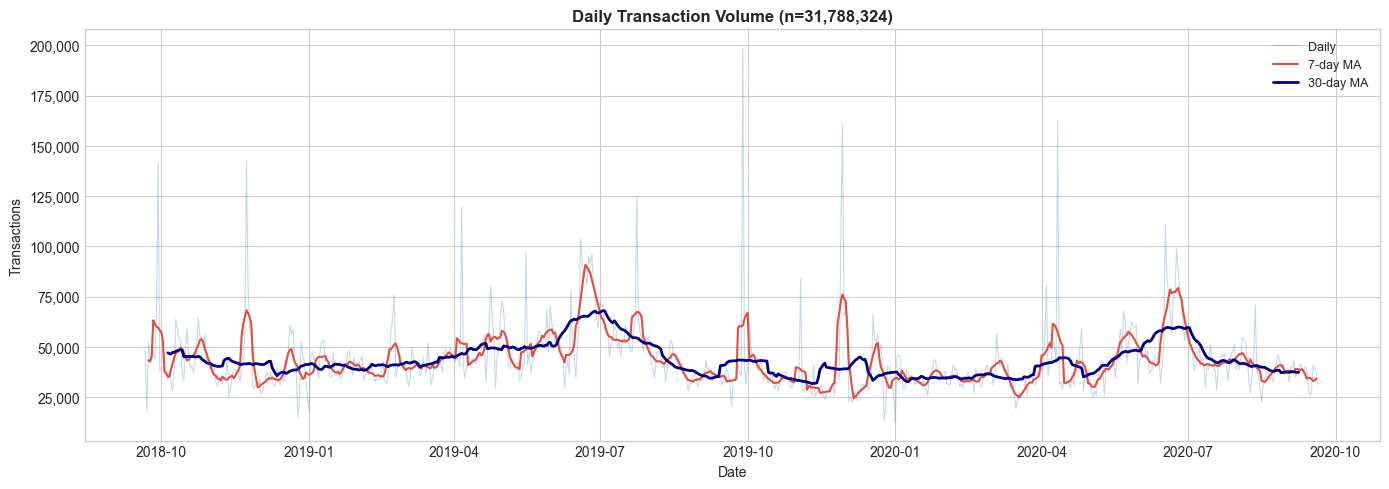

In [15]:
# Daily transaction aggregation (reused in Temporal Split)
df_daily = con.execute(f"""
    SELECT CAST(t_dat AS DATE) as date,
           COUNT(*) as n_transactions,
           AVG(price) as avg_price,
           COUNT(DISTINCT customer_id) as n_users
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    GROUP BY date ORDER BY date
""").df()
df_daily['ma7'] = df_daily['n_transactions'].rolling(7, center=True).mean()
df_daily['ma30'] = df_daily['n_transactions'].rolling(30, center=True).mean()
total_txn = df_daily['n_transactions'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_daily['date'], df_daily['n_transactions'], alpha=0.3, color=COLORS['count'],
        lw=0.8, label='Daily')
ax.plot(df_daily['date'], df_daily['ma7'], color=COLORS['accent'], lw=1.5, label='7-day MA')
ax.plot(df_daily['date'], df_daily['ma30'], color='darkblue', lw=2, label='30-day MA')

ax.set_title(f'Daily Transaction Volume (n={total_txn:,})', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_daily_transactions.png", dpi=150, bbox_inches="tight")
plt.show()

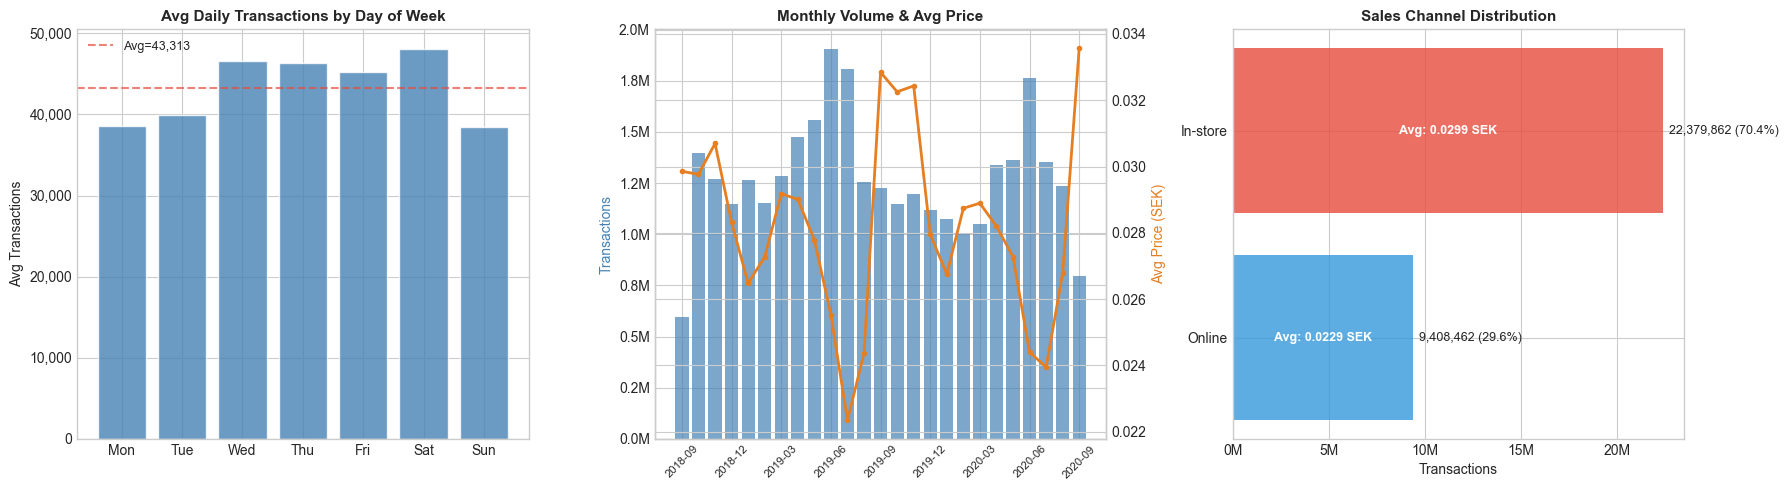

In [16]:
# --- Temporal Decomposition ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (0) Day-of-Week average transactions
df_dow = con.execute(f"""
    WITH daily AS (
        SELECT t_dat, ISODOW(t_dat) as dow, COUNT(*) as cnt
        FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
        GROUP BY t_dat, ISODOW(t_dat)
    )
    SELECT dow, AVG(cnt) as avg_txn FROM daily GROUP BY dow ORDER BY dow
""").df()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0].bar(dow_labels, df_dow['avg_txn'].values, color=COLORS['count'],
            alpha=0.8, edgecolor='white')
avg_all = df_dow['avg_txn'].mean()
axes[0].axhline(avg_all, color=COLORS['accent'], linestyle='--', alpha=0.7,
                label=f'Avg={avg_all:,.0f}')
axes[0].set_title('Avg Daily Transactions by Day of Week', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Avg Transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend(fontsize=9)

# (1) Monthly volume + avg price dual-axis
df_monthly = con.execute(f"""
    SELECT DATE_TRUNC('month', t_dat) as month,
           COUNT(*) as n_txn, AVG(price) as avg_price
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    GROUP BY month ORDER BY month
""").df()
x = range(len(df_monthly))
ax1 = axes[1]
ax1.bar(x, df_monthly['n_txn'], color=COLORS['count'], alpha=0.7, label='Transactions')
ax1.set_ylabel('Transactions', color=COLORS['count'])
ax1.set_title('Monthly Volume & Avg Price', fontsize=11, fontweight='bold')
month_labels = [d.strftime('%Y-%m') for d in pd.to_datetime(df_monthly['month'])]
ax1.set_xticks(list(x)[::3])
ax1.set_xticklabels(month_labels[::3], rotation=45, fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax2 = ax1.twinx()
ax2.plot(x, df_monthly['avg_price'], color=COLORS['monetary'], lw=2,
         marker='o', markersize=3, label='Avg Price')
ax2.set_ylabel('Avg Price (SEK)', color=COLORS['monetary'])

# (2) Sales Channel distribution
df_channel = con.execute(f"""
    SELECT sales_channel_id, COUNT(*) as cnt, AVG(price) as avg_price
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    GROUP BY sales_channel_id ORDER BY sales_channel_id
""").df()
ch_labels_map = {1: 'Online', 2: 'In-store'}
ch_names = [ch_labels_map.get(c, str(c)) for c in df_channel['sales_channel_id']]
ch_colors = [CHANNEL_COLORS.get(c, COLORS['muted']) for c in df_channel['sales_channel_id']]
total_ch = df_channel['cnt'].sum()
bars = axes[2].barh(ch_names, df_channel['cnt'].values, color=ch_colors, alpha=0.8)
for bar, val, avg_p in zip(bars, df_channel['cnt'].values, df_channel['avg_price'].values):
    pct = val / total_ch * 100
    axes[2].text(bar.get_width() + total_ch * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
    axes[2].text(bar.get_width() * 0.5,
                 bar.get_y() + bar.get_height() / 2,
                 f'Avg: {avg_p:.4f} SEK', va='center', ha='center',
                 fontsize=9, color='white', fontweight='bold')
axes[2].set_title('Sales Channel Distribution', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Transactions')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.0f}M'))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_temporal_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

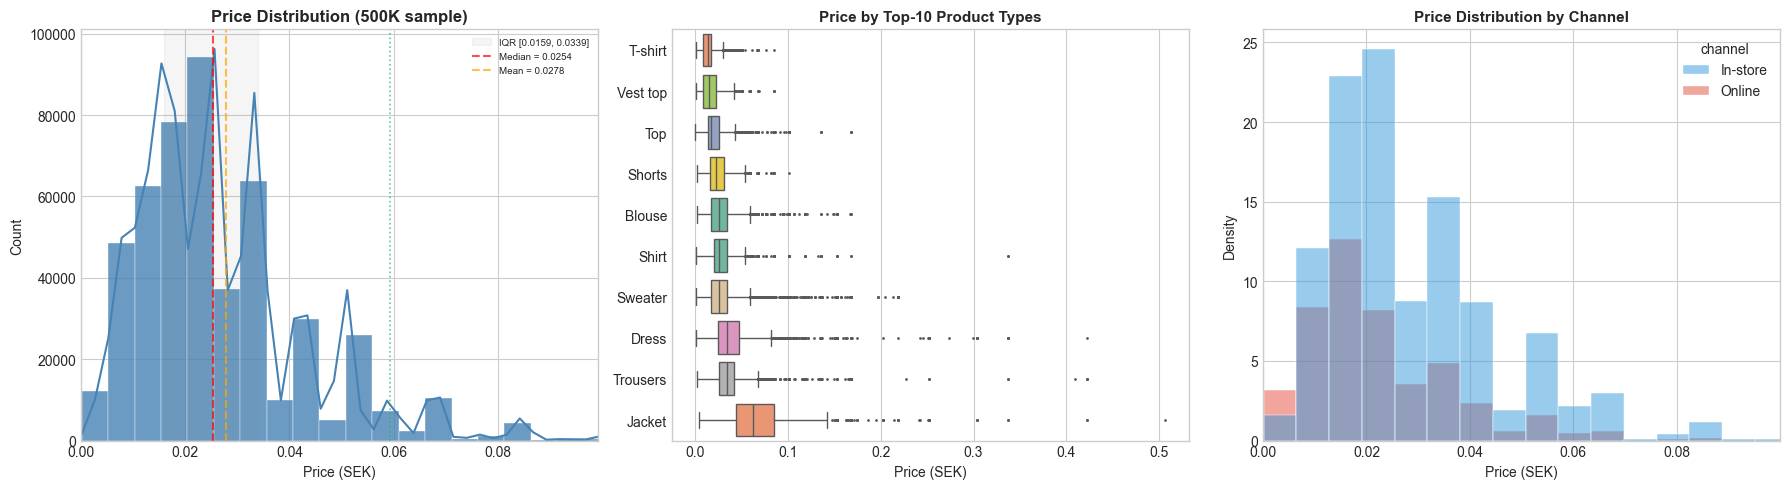

In [17]:
# --- Price Analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (0) Overall price distribution (sampled)
df_price_all = con.execute(f"""
    SELECT price FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    USING SAMPLE 500000
""").df()
plot_hist_with_stats(axes[0], df_price_all['price'], bins=100, color=COLORS['count'],
                     title='Price Distribution (500K sample)', xlabel='Price (SEK)')
p95 = df_price_all['price'].quantile(0.95)
axes[0].axvline(p95, color='#27ae60', linestyle=':', alpha=0.7, lw=1.2)
axes[0].legend(fontsize=7)
axes[0].set_xlim(0, df_price_all['price'].quantile(0.99))

# (1) Top-10 Product Type price boxplot
df_price_type = con.execute(f"""
    WITH top_types AS (
        SELECT product_type_name
        FROM read_csv_auto('{DATA_DIR}/articles.csv')
        GROUP BY product_type_name ORDER BY COUNT(*) DESC LIMIT 10
    )
    SELECT a.product_type_name, t.price
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    WHERE a.product_type_name IN (SELECT product_type_name FROM top_types)
    USING SAMPLE 200000
""").df()
type_order = (df_price_type.groupby('product_type_name')['price']
              .median().sort_values().index.tolist())
sns.boxplot(data=df_price_type, x='price', y='product_type_name',
            hue='product_type_name', order=type_order,
            ax=axes[1], palette='Set2', fliersize=1, legend=False)
axes[1].set_title('Price by Top-10 Product Types', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Price (SEK)')
axes[1].set_ylabel('')

# (2) Sales Channel price comparison
df_ch_price = con.execute(f"""
    SELECT sales_channel_id, price
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    USING SAMPLE 300000
""").df()
df_ch_price['channel'] = df_ch_price['sales_channel_id'].map({1: 'Online', 2: 'In-store'})
sns.histplot(data=df_ch_price, x='price', hue='channel', ax=axes[2],
             bins=80, alpha=0.5, palette=[CHANNEL_COLORS[1], CHANNEL_COLORS[2]],
             edgecolor='white', stat='density')
axes[2].set_title('Price Distribution by Channel', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Price (SEK)')
axes[2].set_xlim(0, df_ch_price['price'].quantile(0.99))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_price_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

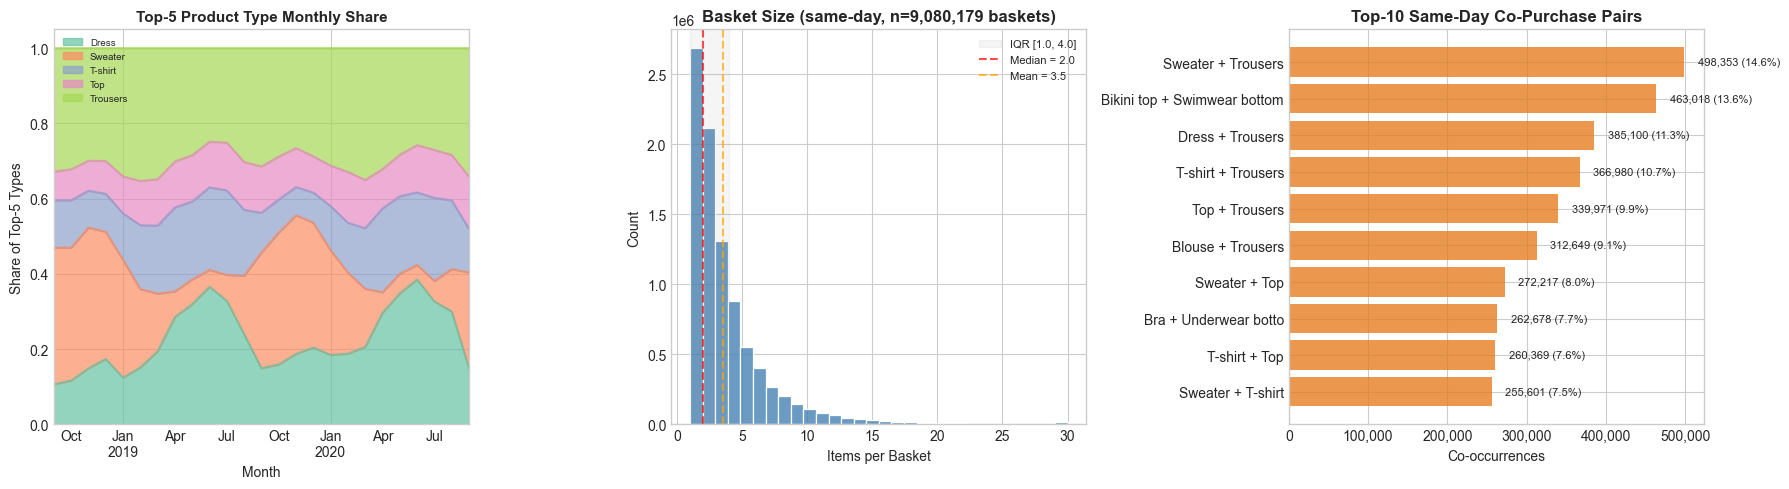

Basket Analysis Summary
Single-item baskets: 29.6%
Multi-item baskets:  70.4%
Avg basket size:     3.50


In [18]:
# --- Seasonal Category Variation + Basket Analysis ---
# (a) Monthly Top-5 product type share (stacked area)
top5_types = con.execute(f"""
    SELECT a.product_type_name, COUNT(*) as cnt
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    GROUP BY a.product_type_name ORDER BY cnt DESC LIMIT 5
""").df()['product_type_name'].tolist()

top5_str = ", ".join([f"'{t}'" for t in top5_types])
df_monthly_type = con.execute(f"""
    SELECT DATE_TRUNC('month', t.t_dat) as month,
           a.product_type_name, COUNT(*) as cnt
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    WHERE a.product_type_name IN ({top5_str})
    GROUP BY month, a.product_type_name ORDER BY month
""").df()
pivot_monthly = df_monthly_type.pivot_table(
    index='month', columns='product_type_name', values='cnt', fill_value=0)
# Normalize to share within each month
pivot_share = pivot_monthly.div(pivot_monthly.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (0) Stacked area: seasonal category variation
pivot_share.plot.area(ax=axes[0], alpha=0.7, stacked=True)
axes[0].set_title('Top-5 Product Type Monthly Share', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Share of Top-5 Types')
axes[0].set_xlabel('Month')
axes[0].legend(fontsize=7, loc='upper left', bbox_to_anchor=(0, 1))

# (b) Basket size distribution (same-day, same-customer)
df_basket = con.execute(f"""
    SELECT customer_id, t_dat, COUNT(*) as basket_size
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    GROUP BY customer_id, t_dat
""").df()

plot_hist_with_stats(axes[1], df_basket['basket_size'].clip(upper=30),
                     bins=30, color=COLORS['count'],
                     title=f'Basket Size (same-day, n={len(df_basket):,} baskets)',
                     xlabel='Items per Basket', show_kde=False)

# (c) Co-purchase product type combos in same-day baskets (basket_size > 1)
df_copurchase = con.execute(f"""
    WITH baskets AS (
        SELECT t.customer_id, t.t_dat, a.product_type_name
        FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
        JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    ),
    multi_baskets AS (
        SELECT customer_id, t_dat
        FROM baskets
        GROUP BY customer_id, t_dat
        HAVING COUNT(*) > 1
    ),
    basket_types AS (
        SELECT DISTINCT b.customer_id, b.t_dat, b.product_type_name
        FROM baskets b
        JOIN multi_baskets m ON b.customer_id = m.customer_id AND b.t_dat = m.t_dat
    )
    SELECT a.product_type_name as type_a, b.product_type_name as type_b, COUNT(*) as cnt
    FROM basket_types a
    JOIN basket_types b ON a.customer_id = b.customer_id AND a.t_dat = b.t_dat
        AND a.product_type_name < b.product_type_name
    GROUP BY type_a, type_b
    ORDER BY cnt DESC
    LIMIT 10
""").df()
combo_labels = df_copurchase.apply(
    lambda r: f"{r['type_a'][:15]} + {r['type_b'][:15]}", axis=1)
combo_series = pd.Series(df_copurchase['cnt'].values, index=combo_labels)
plot_top_n_barh(axes[2], combo_series, n=10, color=COLORS['monetary'],
                title='Top-10 Same-Day Co-Purchase Pairs', xlabel='Co-occurrences')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_seasonal_basket.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
single_basket = (df_basket['basket_size'] == 1).mean()
multi_basket = (df_basket['basket_size'] > 1).mean()
avg_basket = df_basket['basket_size'].mean()
print(f"Basket Analysis Summary")
print(f"{'='*60}")
print(f"Single-item baskets: {single_basket:.1%}")
print(f"Multi-item baskets:  {multi_basket:.1%}")
print(f"Avg basket size:     {avg_basket:.2f}")

### Findings: Transaction Analysis

- **Time Series**: Clear seasonality with peaks in summer (Jun-Jul) and pre-Christmas (Nov). A sharp COVID-19 dip in March 2020 with recovery from April — the model must be robust to distribution shifts
- **Day-of-Week**: 평일 Mon~Fri는 39K~47K로 비교적 균일. Saturday가 최고점(~49K, 평균 대비 +13%). 강한 주중/주말 효과는 아니나, 요일을 카테고리 피처로 포함할 가치 있음
- **Channel Split**: In-store ~70% vs Online ~30% of transactions. In-store 주도이나, Online 서브셋(30%)에서 sequential modeling은 여전히 유효. In-store 평균 가격(0.030)이 Online(0.023)보다 약 30% 높음 — 오프라인 매장의 고가 아이템 편향
- **Price Distribution**: Heavily right-skewed (long tail of premium items). Product types show distinct price ranges (e.g., Dresses higher than T-shirts). Price is a useful feature but requires log-transform or bucketing. Note: prices are Kaggle-normalized values, not raw SEK
- **Seasonal Category Shift**: Top-5 product type share varies by month, confirming seasonal collection cycles in fashion. This validates the need for L3 (occasion/season-based) attributes and time-aware feature engineering
- **Basket Patterns**: Multi-item same-day purchases are common. Top co-purchase pairs (e.g., Trousers+Top, T-shirt+Sweater) reveal outfit-level shopping behavior — the KAR reasoning expert should model complementary item relationships for L3 attributes

## 5. User Behavior Analysis

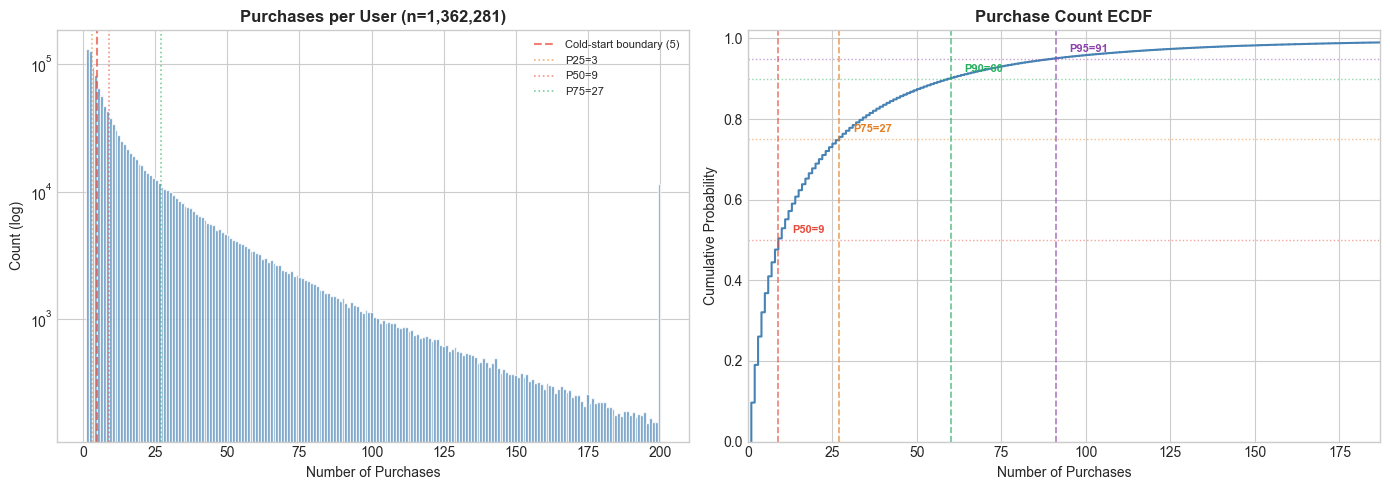

Median: 9  |  Mean: 23.3
Cold-start (1-4 purchases): 436,723 (32.1%)
Active (5+ purchases): 925,558 (67.9%)


In [19]:
# User purchase counts (reused in Cold-start analysis)
df_user_counts = con.execute(f"""
    SELECT customer_id, COUNT(*) as n_purchases
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    GROUP BY customer_id
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (0) Purchase count histogram (log-y) + cold-start boundary
axes[0].hist(df_user_counts['n_purchases'].clip(upper=200), bins=200,
             color=COLORS['count'], alpha=0.8, edgecolor='white', log=True)
axes[0].axvline(5, color=COLORS['accent'], linestyle='--', alpha=0.7, lw=1.5,
                label='Cold-start boundary (5)')
for q, c in [(0.25, '#e67e22'), (0.5, '#e74c3c'), (0.75, '#27ae60')]:
    val = df_user_counts['n_purchases'].quantile(q)
    axes[0].axvline(val, color=c, linestyle=':', alpha=0.6, lw=1.2,
                    label=f'P{int(q*100)}={val:.0f}')
axes[0].set_title(f'Purchases per User (n={len(df_user_counts):,})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Purchases')
axes[0].set_ylabel('Count (log)')
axes[0].legend(fontsize=8)

# (1) ECDF + quantile annotations
plot_ecdf_with_quantiles(axes[1], df_user_counts['n_purchases'],
                         quantiles=(0.5, 0.75, 0.9, 0.95),
                         title='Purchase Count ECDF', xlabel='Number of Purchases')
axes[1].set_xlim(0, df_user_counts['n_purchases'].quantile(0.99))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_user_purchase_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
med = df_user_counts['n_purchases'].median()
mean = df_user_counts['n_purchases'].mean()
cold_n = (df_user_counts['n_purchases'] < 5).sum()
active_n = (df_user_counts['n_purchases'] >= 5).sum()
print(f"Median: {med:.0f}  |  Mean: {mean:.1f}")
print(f"Cold-start (1-4 purchases): {cold_n:,} ({cold_n/len(df_user_counts):.1%})")
print(f"Active (5+ purchases): {active_n:,} ({active_n/len(df_user_counts):.1%})")

User Segments vs Transaction Share
  Light(1-4)     :  436,723 users (32.1%)  ->   1,001,782 txn ( 3.2%)
  Moderate(5-27) :  592,688 users (43.5%)  ->   7,430,139 txn (23.4%)
  Heavy(28+)     :  332,870 users (24.4%)  ->  23,356,403 txn (73.5%)


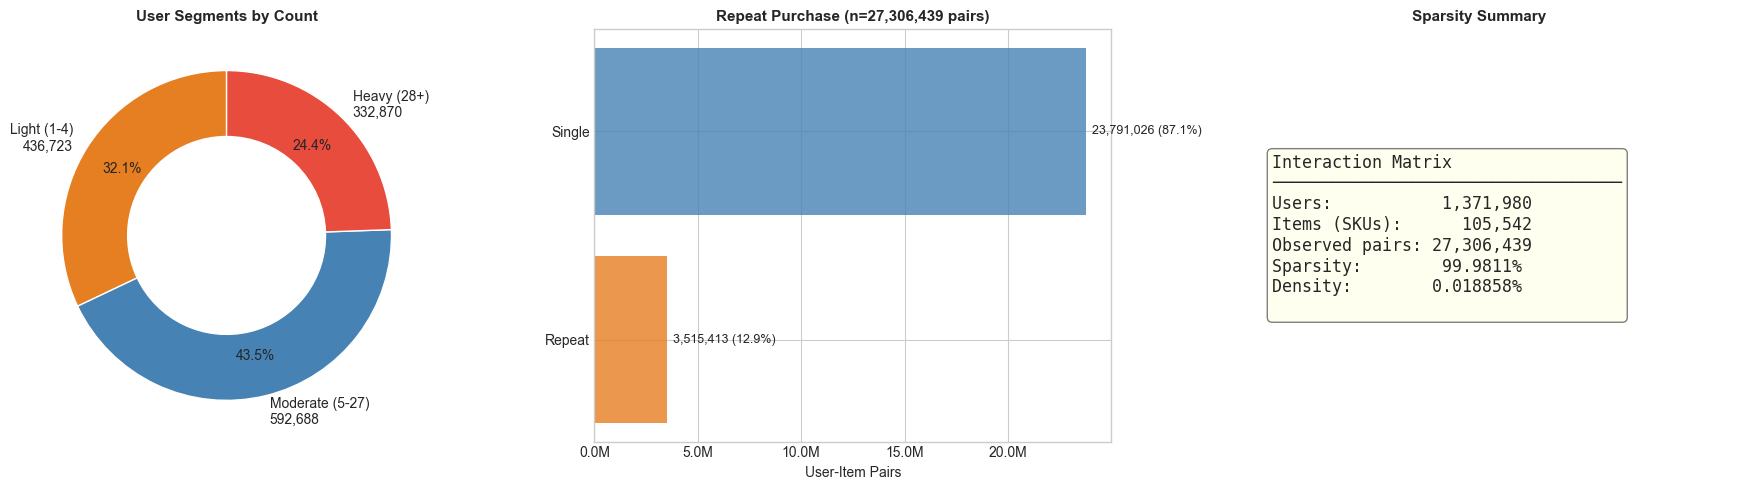

In [20]:
# --- Cold-start & Sparsity Analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (0) User segment donut
light = df_user_counts.query('n_purchases < 5')
moderate = df_user_counts.query('5 <= n_purchases < 28')
heavy = df_user_counts.query('n_purchases >= 28')

seg_users = [len(light), len(moderate), len(heavy)]
seg_labels = [f'Light (1-4)\n{seg_users[0]:,}',
              f'Moderate (5-27)\n{seg_users[1]:,}',
              f'Heavy (28+)\n{seg_users[2]:,}']
seg_colors = ['#e67e22', COLORS['count'], COLORS['accent']]
axes[0].pie(seg_users, labels=seg_labels, colors=seg_colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.4, edgecolor='white'))
axes[0].set_title('User Segments by Count', fontsize=11, fontweight='bold')

seg_txn = [light['n_purchases'].sum(), moderate['n_purchases'].sum(),
           heavy['n_purchases'].sum()]
print(f"User Segments vs Transaction Share")
print(f"{'='*60}")
for label, nu, nt in zip(['Light(1-4)', 'Moderate(5-27)', 'Heavy(28+)'],
                          seg_users, seg_txn):
    print(f"  {label:15s}: {nu:>8,} users ({nu/sum(seg_users):5.1%})"
          f"  ->  {nt:>10,} txn ({nt/sum(seg_txn):5.1%})")

# (1) Repeat purchase analysis
repeat_stats = con.execute(f"""
    WITH pairs AS (
        SELECT customer_id, article_id, COUNT(*) as cnt
        FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
        GROUP BY customer_id, article_id
    )
    SELECT
        COUNT(*) as total_pairs,
        SUM(CASE WHEN cnt = 1 THEN 1 ELSE 0 END) as single,
        SUM(CASE WHEN cnt > 1 THEN 1 ELSE 0 END) as repeat_cnt
    FROM pairs
""").fetchone()
total_p, single_p, repeat_p = repeat_stats
axes[1].barh(['Repeat', 'Single'],
             [repeat_p, single_p],
             color=[COLORS['monetary'], COLORS['count']], alpha=0.8)
for i, (val, name) in enumerate(zip([repeat_p, single_p], ['Repeat', 'Single'])):
    axes[1].text(val + total_p * 0.01, i,
                 f'{val:,} ({val/total_p:.1%})', va='center', fontsize=9)
axes[1].set_title(f'Repeat Purchase (n={total_p:,} pairs)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('User-Item Pairs')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))

# (2) Sparsity summary
axes[2].axis('off')
sparsity_text = (
    f"Interaction Matrix\n"
    f"{'─'*35}\n"
    f"Users:          {n_customers:>10,}\n"
    f"Items (SKUs):   {n_articles:>10,}\n"
    f"Observed pairs: {n_pairs:>10,}\n"
    f"Sparsity:       {sparsity:>9.4%}\n"
    f"Density:        {1-sparsity:>9.6%}\n"
)
axes[2].text(0.1, 0.5, sparsity_text, transform=axes[2].transAxes,
             fontsize=12, family='monospace', verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
axes[2].set_title('Sparsity Summary', fontsize=11, fontweight='bold')

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_coldstart_sparsity.png", dpi=150, bbox_inches="tight")
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

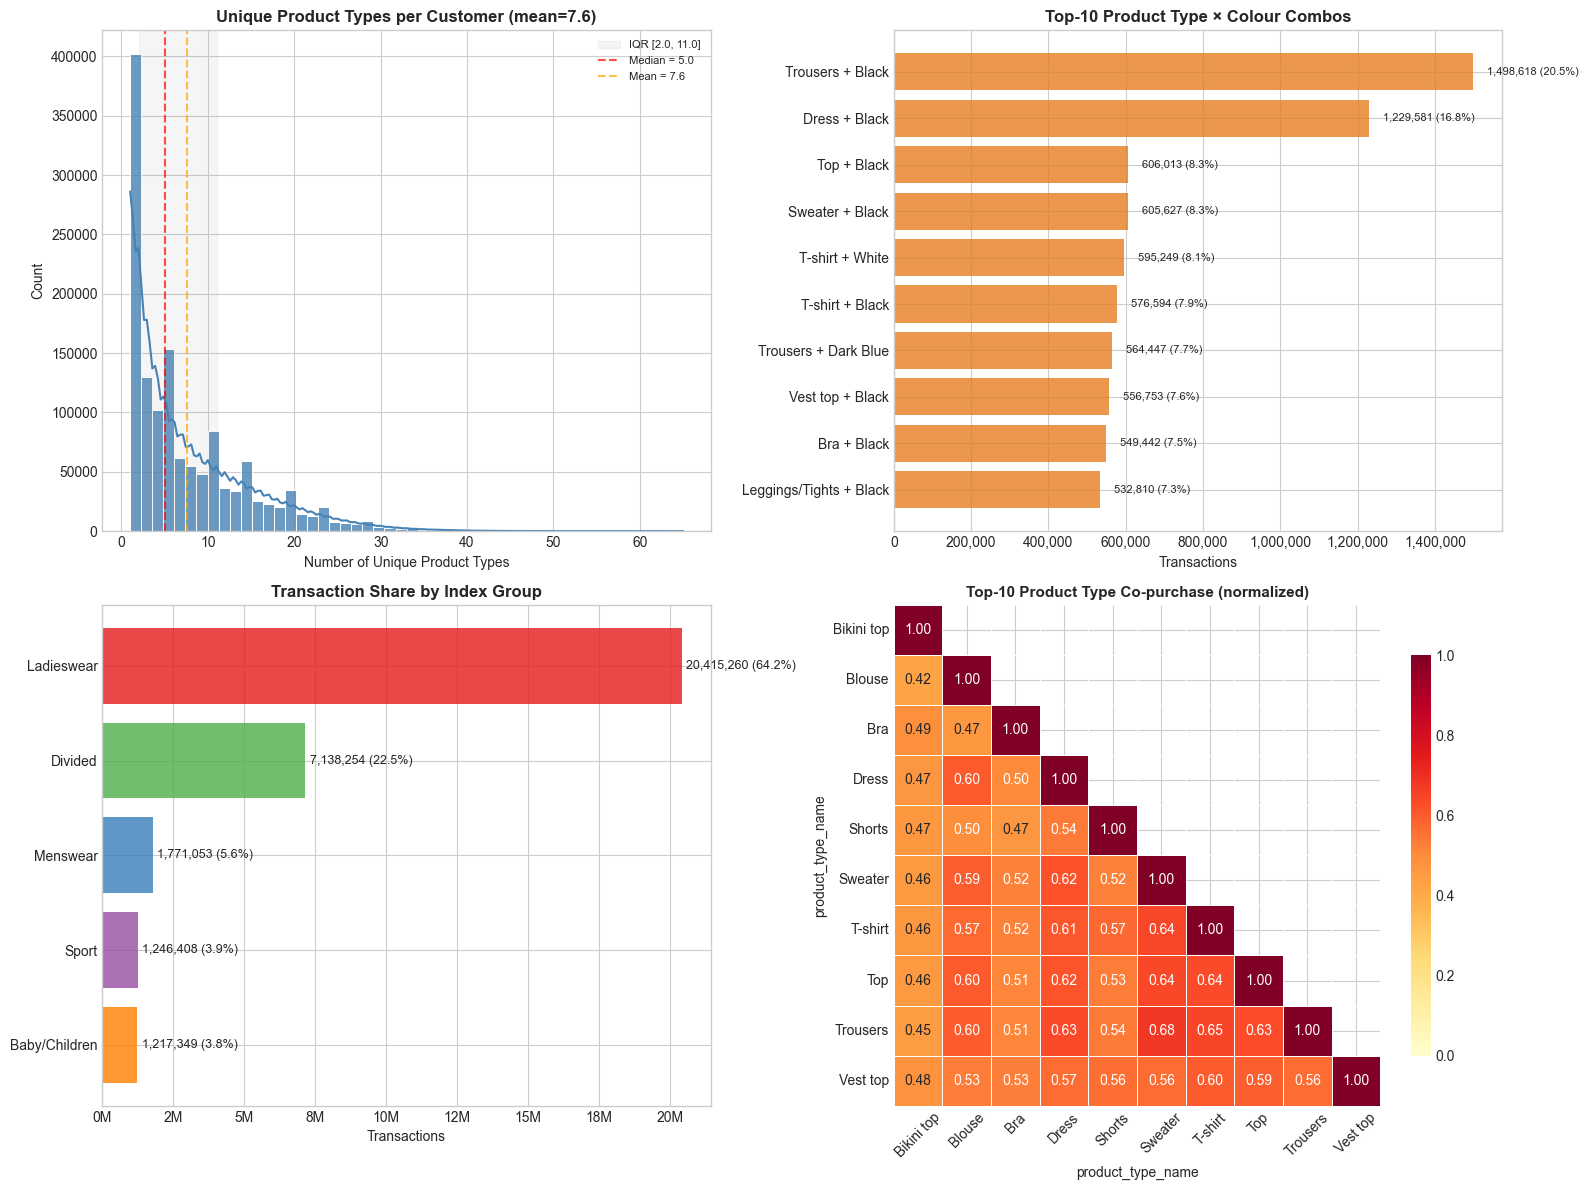

In [21]:
# --- Preference Analysis ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (0,0) Unique product types per user
df_user_diversity = con.execute(f"""
    SELECT t.customer_id, COUNT(DISTINCT a.product_type_name) as n_types
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    GROUP BY t.customer_id
""").df()
mean_div = df_user_diversity['n_types'].mean()
plot_hist_with_stats(axes[0, 0], df_user_diversity['n_types'], bins=50, color=COLORS['count'],
                     title=f'Unique Product Types per Customer (mean={mean_div:.1f})',
                     xlabel='Number of Unique Product Types')

# (0,1) Top-10 (Product Type × Colour) combinations
df_type_color = con.execute(f"""
    SELECT a.product_type_name || ' + ' || a.colour_group_name as combo, COUNT(*) as cnt
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    GROUP BY combo ORDER BY cnt DESC LIMIT 10
""").df()
tc_series = df_type_color.set_index('combo')['cnt']
plot_top_n_barh(axes[0, 1], tc_series, n=10, color=COLORS['monetary'],
                title='Top-10 Product Type × Colour Combos', xlabel='Transactions')

# (1,0) Index Group transaction share
df_idx = con.execute(f"""
    SELECT a.index_group_name, COUNT(*) as cnt
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    GROUP BY a.index_group_name ORDER BY cnt DESC
""").df()
idx_series = df_idx.set_index('index_group_name')['cnt']
idx_colors = [INDEX_COLORS.get(name, COLORS['muted']) for name in idx_series.index[::-1]]
bars = axes[1, 0].barh(idx_series.index[::-1].astype(str), idx_series.values[::-1],
                        color=idx_colors, alpha=0.8)
total_idx = idx_series.sum()
for bar, val in zip(bars, idx_series.values[::-1]):
    pct = val / total_idx * 100
    axes[1, 0].text(bar.get_width() + total_idx * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
axes[1, 0].set_title('Transaction Share by Index Group', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Transactions')
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.0f}M'))

# (1,1) Top-10 Product Type co-purchase heatmap
df_user_type_ind = con.execute(f"""
    WITH top_types AS (
        SELECT product_type_name FROM (
            SELECT a.product_type_name, COUNT(*) as cnt
            FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
            JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
            GROUP BY a.product_type_name ORDER BY cnt DESC LIMIT 10
        )
    )
    SELECT DISTINCT t.customer_id, a.product_type_name
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv') t
    JOIN read_csv_auto('{DATA_DIR}/articles.csv') a ON t.article_id = a.article_id
    WHERE a.product_type_name IN (SELECT product_type_name FROM top_types)
""").df()
indicator = pd.crosstab(df_user_type_ind['customer_id'],
                         df_user_type_ind['product_type_name']).clip(upper=1)
co_matrix = indicator.T.dot(indicator)
diag = np.diag(co_matrix.values).astype(float)
diag[diag == 0] = 1
co_norm = co_matrix.values / np.sqrt(np.outer(diag, diag))
co_norm_df = pd.DataFrame(co_norm, index=co_matrix.index, columns=co_matrix.columns)
mask = np.triu(np.ones_like(co_norm, dtype=bool), k=1)
sns.heatmap(co_norm_df, annot=True, fmt='.2f', cmap='YlOrRd', mask=mask,
            linewidths=0.5, ax=axes[1, 1], cbar_kws={'shrink': 0.8}, vmin=0, vmax=1)
axes[1, 1].set_title('Top-10 Product Type Co-purchase (normalized)',
                     fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].tick_params(axis='y', rotation=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_preference_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings: User Behavior Analysis

**1. Purchase Distribution — Extreme Right Skew**

The purchase-per-user distribution exhibits extreme right skew: **median = 9 vs mean = 23.3** (2.6x gap). The percentile breakdown (P50=9, P75=27, P90=60, P95=91) reveals that the vast majority of users have very few interactions relative to the catalog size. With 105K items, even a user at the 75th percentile has interacted with only 0.026% of available products. This means per-user embedding learning is fundamentally **data-starved** for most of the user base — a core motivation for content-based augmentation.

**2. Segment Imbalance — Pareto Effect**

The user segments show a pronounced Pareto pattern:
- **Heavy (28+ purchases)**: 24.4% of users → **73.5%** of transactions
- **Moderate (5-27)**: 43.5% of users → 23.4% of transactions
- **Light (1-4)**: 32.1% of users → **3.2%** of transactions

Collaborative filtering models are inherently biased toward Heavy users who generate the vast majority of training signal. The 436K Light users receive degraded recommendations because their sparse interactions produce noisy, unreliable user embeddings.

**3. Cold-start Severity — Why CF Is Fundamentally Insufficient**

The cold-start problem in this dataset operates at three compounding levels:

- **User-side sparsity**: 32.1% of users (436K) have only 1-4 purchases. Against a 105K-item catalog, this represents **< 0.004%** of possible interactions per user — far below the threshold for meaningful preference learning
- **Matrix-side sparsity**: The overall interaction matrix is **99.98% sparse** (0.02% density). At this sparsity level, neither matrix factorization (MF) nor graph neural networks (LightGCN) can propagate meaningful collaborative signal — most user-item paths simply don't exist
- **Signal-to-noise mechanism**: Sparse interactions → noisy user embeddings → effectively random ranking for Light users. This explains why in baseline experiments, **Popularity (Global) > UserKNN > BPR-MF** — the less a model relies on per-user interaction data, the better it performs for the majority of users

This **triple-sparsity** problem (user-level × matrix-level × signal quality) is the core motivation for L1+L2+L3 content-based augmentation: attributes provide dense, reliable item representations that don't depend on interaction history.

**4. Why Faiss ANN Resolves Cold-start Retrieval**

Content-based candidate generation via Faiss ANN fundamentally bypasses the CF cold-start barrier:

- **Dense item representations**: All 105K items have L1+L2+L3 attribute vectors encoded by BGE-base (768-dim), regardless of interaction history. Every item — including zero-purchase long-tail items — has a rich, semantically meaningful representation
- **Minimal user signal required**: Even a single purchase provides enough information to construct a query vector in attribute space. For zero-purchase users, demographic features (age, club status) or contextual signals can generate a reasonable query
- **Faiss HNSW performance**: Approximate nearest neighbor search completes in **< 5ms**, enabling real-time content-based retrieval that **completely bypasses CF signal**
- **Practical example**: A user with 1 cotton T-shirt purchase → query encodes L1 (cotton, jersey knit), L2 (casual comfort, breathable), L3 (everyday basics, layering piece) → Faiss retrieves semantically similar items across the full catalog

**5. Why Reasoning Expert > Repeat Prediction**

The 87% single-purchase rate across user-item pairs makes repeat-purchase prediction fundamentally uninformative:

- **Statistical futility**: 87% of user-item interactions are one-time. A repeat prediction model's majority class is "No" for 87% of pairs — predicting "won't repurchase" is trivially correct but useless for recommendation
- **Fashion is discovery-oriented**: Users don't stop buying — they buy **different** items. The goal is not "will user X buy item Y again?" but "what **new** item Z will user X want next?"
- **Reasoning expert advantage**: Given sparse history, the reasoning expert infers **latent preferences** — style affinity, occasion needs, complementary relationships — that generalize beyond observed items. It answers "why might this user like something new?" rather than "will they repeat?"
- **L2+L3 as semantic bridge**: L2 (experiential: comfort, confidence, versatility) and L3 (theory-based: occasion suitability, style archetype, wardrobe role) attributes provide the semantic vocabulary for reasoning about **why a user would like an unseen item**, connecting sparse purchase history to rich item descriptions

**6. Preference Diversity & Ladieswear Dominance**

- Users explore an average of **~7.6 unique product types**, indicating broad category-level preferences. Top co-purchase pairs (Trousers + T-shirt, Top + Dress) reveal outfit-level shopping patterns that L3 (occasion/theory-based) attributes can capture
- **Ladieswear dominates** at ~60%+ of all transactions. The co-purchase heatmap shows strong within-category affinity, making cross-category recommendation both challenging and high-value for diversity metrics

## 6. Item Popularity Analysis

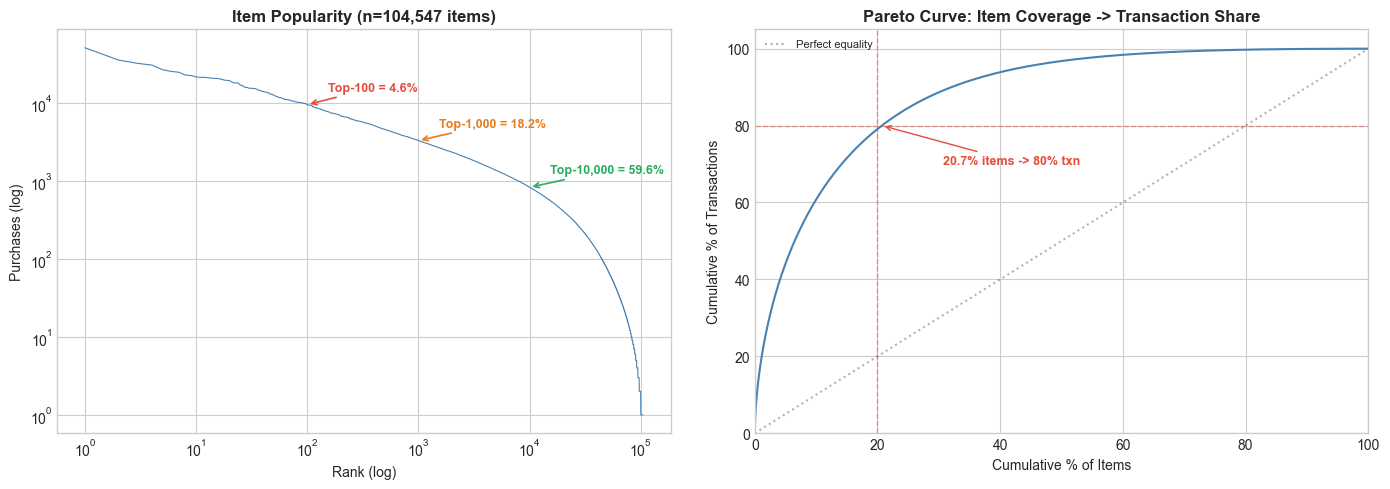

In [22]:
# Item purchase counts (reused in Coverage)
df_item_counts = con.execute(f"""
    SELECT article_id, COUNT(*) as n_purchases
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    GROUP BY article_id
""").df()
df_item_sorted = (df_item_counts.sort_values('n_purchases', ascending=False)
                  .reset_index(drop=True))
df_item_sorted['rank'] = range(1, len(df_item_sorted) + 1)
df_item_sorted['cum_pct'] = (df_item_sorted['n_purchases'].cumsum()
                              / df_item_sorted['n_purchases'].sum())
total_item_txn = df_item_sorted['n_purchases'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (0) Log-log rank-frequency + Top-K annotations
axes[0].loglog(df_item_sorted['rank'], df_item_sorted['n_purchases'],
               lw=0.8, color=COLORS['count'])
for k, c in [(100, '#e74c3c'), (1000, '#e67e22'), (10000, '#27ae60')]:
    pct = df_item_sorted.head(k)['n_purchases'].sum() / total_item_txn
    axes[0].annotate(
        f'Top-{k:,} = {pct:.1%}',
        xy=(k, df_item_sorted.iloc[k-1]['n_purchases']),
        xytext=(15, 10), textcoords='offset points', fontsize=9,
        color=c, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=c, lw=1.2),
    )
axes[0].set_title(f'Item Popularity (n={len(df_item_sorted):,} items)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rank (log)')
axes[0].set_ylabel('Purchases (log)')

# (1) Pareto curve + 80/20 reference
item_pct = np.arange(1, len(df_item_sorted) + 1) / len(df_item_sorted) * 100
axes[1].plot(item_pct, df_item_sorted['cum_pct'] * 100, lw=1.5, color=COLORS['count'])
axes[1].axhline(80, color=COLORS['accent'], linestyle='--', alpha=0.5, lw=1)
axes[1].axvline(20, color=COLORS['accent'], linestyle='--', alpha=0.5, lw=1)
x_80 = item_pct[np.searchsorted(df_item_sorted['cum_pct'].values, 0.8)]
axes[1].annotate(
    f'{x_80:.1f}% items -> 80% txn', xy=(x_80, 80),
    xytext=(x_80 + 10, 70), fontsize=9, fontweight='bold', color=COLORS['accent'],
    arrowprops=dict(arrowstyle='->', color=COLORS['accent']),
)
axes[1].plot([0, 100], [0, 100], 'k:', alpha=0.3, label='Perfect equality')
axes[1].set_title('Pareto Curve: Item Coverage -> Transaction Share',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cumulative % of Items')
axes[1].set_ylabel('Cumulative % of Transactions')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_item_popularity.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# --- Item Coverage Statistics ---
total_items = len(df_item_sorted)
n_single = (df_item_sorted['n_purchases'] == 1).sum()
n_under10 = (df_item_sorted['n_purchases'] < 10).sum()
n_over100 = (df_item_sorted['n_purchases'] >= 100).sum()

# Gini coefficient
sorted_vals = np.sort(df_item_sorted['n_purchases'].values)
n_i = len(sorted_vals)
index_arr = np.arange(1, n_i + 1)
gini = (2 * np.sum(index_arr * sorted_vals) / (n_i * np.sum(sorted_vals))) - (n_i + 1) / n_i

print(f"Item Coverage Statistics")
print(f"{'='*60}")
print(f"1명만 구매한 아이템: {n_single:,} ({n_single/total_items:.1%})")
print(f"10건 미만 아이템:    {n_under10:,} ({n_under10/total_items:.1%})")
print(f"100건 이상 아이템:   {n_over100:,} ({n_over100/total_items:.1%})")
print(f"Gini coefficient:   {gini:.4f}")

Item Coverage Statistics
1명만 구매한 아이템: 4,491 (4.3%)
10건 미만 아이템:    21,228 (20.3%)
100건 이상 아이템:   44,671 (42.7%)
Gini coefficient:   0.7586


### Findings: Item Popularity Analysis

- **Long-tail Distribution**: Gini coefficient = **0.7586**, confirming severe popularity concentration. Top-100 items capture **4.6%** of all transactions; Top-1,000 = **18.2%**; Top-10,000 = **59.6%**
- **Pareto Pattern**: **20.7% of items** drive 80% of transactions — classic long-tail. 20.3% of items have fewer than 10 purchases, and 4.3% have exactly 1 purchase (extreme tail)
- **Content-based Necessity**: 42.7% of items have 100+ purchases (sufficient collaborative signal), but the remaining 57.3% need content-based augmentation. L1+L2+L3 attributes are critical for these tail items
- **Diversity Opportunity**: Popularity-based methods will over-recommend head items. The KAR factual expert (encoding L1+L2+L3 attributes) can surface relevant tail items, improving both NDCG and catalog coverage

## 7. Temporal Split Validation

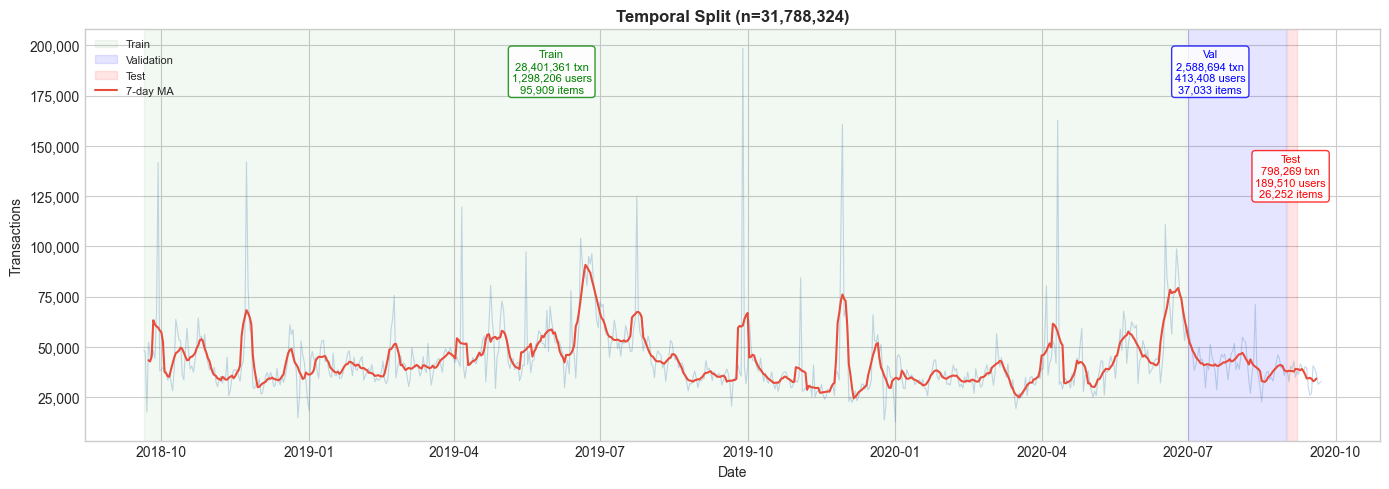

In [24]:
train_end = pd.Timestamp('2020-06-30')
val_start = pd.Timestamp('2020-07-01')
val_end = pd.Timestamp('2020-08-31')
test_start = pd.Timestamp('2020-09-01')
test_end = pd.Timestamp('2020-09-07')

fig, ax = plt.subplots(figsize=(14, 5))

# Background spans
ax.axvspan(df_daily['date'].min(), train_end, alpha=0.05, color='green', label='Train')
ax.axvspan(val_start, val_end, alpha=0.1, color='blue', label='Validation')
ax.axvspan(test_start, test_end, alpha=0.1, color='red', label='Test')

# Daily + 7-day MA
ax.plot(df_daily['date'], df_daily['n_transactions'], alpha=0.3,
        color=COLORS['count'], lw=0.8)
ax.plot(df_daily['date'], df_daily['ma7'], color=COLORS['accent'], lw=1.5,
        label='7-day MA')

# Split statistics
split_stats = con.execute(f"""
    SELECT
        CASE
            WHEN t_dat <= '2020-06-30' THEN 'Train'
            WHEN t_dat <= '2020-08-31' THEN 'Val'
            ELSE 'Test'
        END as split,
        COUNT(*) as n_txn,
        COUNT(DISTINCT customer_id) as n_users,
        COUNT(DISTINCT article_id) as n_items
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    GROUP BY split
""").df()
stats_dict = split_stats.set_index('split').to_dict('index')

ymax = ax.get_ylim()[1]
positions = {
    'Train': (pd.Timestamp('2019-06-01'), ymax * 0.85, 'green'),
    'Val':   (pd.Timestamp('2020-07-15'), ymax * 0.85, 'blue'),
    'Test':  (pd.Timestamp('2020-09-03'), ymax * 0.60, 'red'),
}
for split_name, (x_pos, y_pos, color) in positions.items():
    if split_name in stats_dict:
        s = stats_dict[split_name]
        text = (f"{split_name}\n{s['n_txn']:,.0f} txn\n"
                f"{s['n_users']:,.0f} users\n{s['n_items']:,.0f} items")
        ax.text(x_pos, y_pos, text, fontsize=8, color=color, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.8))

ax.set_title(f'Temporal Split (n={total_txn:,})', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_temporal_split.png", dpi=150, bbox_inches="tight")
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

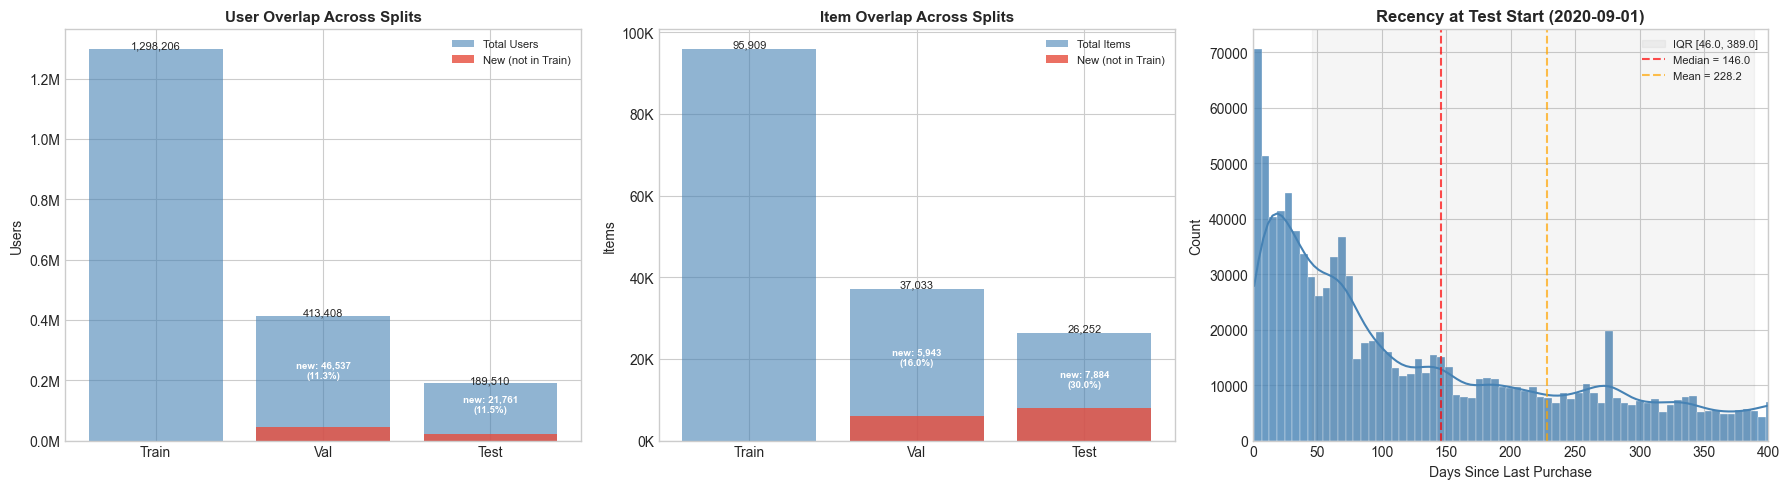

Split Overlap Summary
Users — Val new: 46,537 (11.3%)  | Test new: 21,761 (11.5%)
Items — Val new: 5,943 (16.0%)  | Test new: 7,884 (30.0%)
Recency — Median: 146 days  | Mean: 228 days
Active within 30d: 18.5%  |  Active within 90d: 40.0%


In [25]:
# --- Val/Test Overlap & Recency Analysis ---
# User and item overlap across splits
overlap = con.execute(f"""
    WITH split_data AS (
        SELECT *,
            CASE WHEN t_dat <= '2020-06-30' THEN 'train'
                 WHEN t_dat <= '2020-08-31' THEN 'val'
                 ELSE 'test' END as split
        FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    ),
    train_users AS (SELECT DISTINCT customer_id FROM split_data WHERE split='train'),
    val_users AS (SELECT DISTINCT customer_id FROM split_data WHERE split='val'),
    test_users AS (SELECT DISTINCT customer_id FROM split_data WHERE split='test'),
    train_items AS (SELECT DISTINCT article_id FROM split_data WHERE split='train'),
    val_items AS (SELECT DISTINCT article_id FROM split_data WHERE split='val'),
    test_items AS (SELECT DISTINCT article_id FROM split_data WHERE split='test')
    SELECT
        (SELECT COUNT(*) FROM train_users) as train_users,
        (SELECT COUNT(*) FROM val_users) as val_users,
        (SELECT COUNT(*) FROM test_users) as test_users,
        (SELECT COUNT(*) FROM train_users WHERE customer_id IN (SELECT customer_id FROM val_users)) as train_val_user_overlap,
        (SELECT COUNT(*) FROM train_users WHERE customer_id IN (SELECT customer_id FROM test_users)) as train_test_user_overlap,
        (SELECT COUNT(*) FROM val_users WHERE customer_id NOT IN (SELECT customer_id FROM train_users)) as val_new_users,
        (SELECT COUNT(*) FROM test_users WHERE customer_id NOT IN (SELECT customer_id FROM train_users)) as test_new_users,
        (SELECT COUNT(*) FROM train_items) as train_items,
        (SELECT COUNT(*) FROM val_items) as val_items,
        (SELECT COUNT(*) FROM test_items) as test_items,
        (SELECT COUNT(*) FROM val_items WHERE article_id NOT IN (SELECT article_id FROM train_items)) as val_new_items,
        (SELECT COUNT(*) FROM test_items WHERE article_id NOT IN (SELECT article_id FROM train_items)) as test_new_items
""").fetchone()

(train_u, val_u, test_u, tv_user_ol, tt_user_ol, val_new_u, test_new_u,
 train_i, val_i, test_i, val_new_i, test_new_i) = overlap

# Recency: days since last purchase at test_start
df_recency = con.execute(f"""
    SELECT customer_id, MAX(t_dat) as last_purchase,
           DATEDIFF('day', MAX(t_dat), DATE '2020-09-01') as recency_days
    FROM read_csv_auto('{DATA_DIR}/transactions_train.csv')
    WHERE t_dat <= '2020-08-31'
    GROUP BY customer_id
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (0) User overlap bar chart
split_names = ['Train', 'Val', 'Test']
user_counts = [train_u, val_u, test_u]
overlap_counts = [train_u, tv_user_ol, tt_user_ol]
new_counts = [0, val_new_u, test_new_u]

x_pos = range(3)
bars1 = axes[0].bar(x_pos, user_counts, color=COLORS['count'], alpha=0.6,
                    label='Total Users')
bars2 = axes[0].bar(x_pos, new_counts, color=COLORS['accent'], alpha=0.8,
                    bottom=[0]*3, label='New (not in Train)')
for bar, total, new in zip(bars1, user_counts, new_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{total:,}', ha='center', fontsize=8)
    if new > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                     f'new: {new:,}\n({new/total:.1%})', ha='center',
                     fontsize=7, color='white', fontweight='bold')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(split_names)
axes[0].set_title('User Overlap Across Splits', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
axes[0].legend(fontsize=8)

# (1) Item overlap bar chart
item_counts = [train_i, val_i, test_i]
new_item_counts = [0, val_new_i, test_new_i]
bars1 = axes[1].bar(x_pos, item_counts, color=COLORS['count'], alpha=0.6,
                    label='Total Items')
bars2 = axes[1].bar(x_pos, new_item_counts, color=COLORS['accent'], alpha=0.8,
                    bottom=[0]*3, label='New (not in Train)')
for bar, total, new in zip(bars1, item_counts, new_item_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{total:,}', ha='center', fontsize=8)
    if new > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                     f'new: {new:,}\n({new/total:.1%})', ha='center',
                     fontsize=7, color='white', fontweight='bold')
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(split_names)
axes[1].set_title('Item Overlap Across Splits', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Items')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}K'))
axes[1].legend(fontsize=8)

# (2) Recency distribution at test time
plot_hist_with_stats(axes[2], df_recency['recency_days'],
                     bins=120, color=COLORS['count'],
                     title='Recency at Test Start (2020-09-01)',
                     xlabel='Days Since Last Purchase')
axes[2].set_xlim(0, 400)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "00_eda_split_overlap_recency.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
print(f"Split Overlap Summary")
print(f"{'='*60}")
print(f"Users — Val new: {val_new_u:,} ({val_new_u/val_u:.1%})  "
      f"| Test new: {test_new_u:,} ({test_new_u/test_u:.1%})")
print(f"Items — Val new: {val_new_i:,} ({val_new_i/val_i:.1%})  "
      f"| Test new: {test_new_i:,} ({test_new_i/test_i:.1%})")
print(f"Recency — Median: {df_recency['recency_days'].median():.0f} days  "
      f"| Mean: {df_recency['recency_days'].mean():.0f} days")
active_30d = (df_recency['recency_days'] <= 30).mean()
active_90d = (df_recency['recency_days'] <= 90).mean()
print(f"Active within 30d: {active_30d:.1%}  |  Active within 90d: {active_90d:.1%}")

### Findings: Temporal Split Validation

> Figures: `results/figures/00_eda_temporal_split.png`, `results/figures/00_eda_split_overlap_recency.png`

**Split Design & Volume:**

| Split | Period | Transactions | Users | Items | Share |
|-------|--------|-------------|-------|-------|-------|
| Train | 2018-09 ~ 2020-06 | 28,401,361 | 1,298,206 | 95,909 | 89.3% |
| Val | 2020-07 ~ 2020-08 | 2,588,694 | 413,408 | 37,033 | 8.2% |
| Test | 2020-09-01 ~ 09-07 | 798,269 | 189,510 | 26,252 | 2.5% |

- Strict chronological ordering — no future data leakage. Test 1-week window matches the original Kaggle competition MAP@12 format
- 7-day MA shows comparable volume across Val/Test (post-COVID recovery), suggesting no severe distribution shift between tuning and evaluation

**Cold-Start at Evaluation Time:**

| Dimension | Val (new, not in Train) | Test (new, not in Train) |
|-----------|------------------------|-------------------------|
| Users | 46,537 (**11.3%**) | 21,761 (**11.5%**) |
| Items | 5,943 (**16.0%**) | 7,884 (**30.0%**) |

- ~11% new users in both splits — consistent cold-start rate; these users have zero CF signal and require attribute-based or demographic proxy recommendations
- **Test new items (30.0%) nearly double Val (16.0%)** — September marks fall season launch with a surge of new products. These 7,884 items have no Train interactions, making L1+L2+L3 attribute vectors their only dense representation
- The Val→Test escalation of item cold-start quantifies how seasonal turnover amplifies Triple-Sparsity at evaluation time

**User Recency at Test Start (2020-09-01):**

| Metric | Value |
|--------|-------|
| Median recency | 146 days (~5 months) |
| Mean recency | 228 days (~7.5 months) |
| IQR | [46, 365] days |
| Active within 30 days | 18.5% |
| Active within 90 days | 40.0% |

- **60% of users inactive for 90+ days** — high preference drift risk; CF embeddings trained on stale interactions may not reflect current preferences
- Right-skewed distribution: a small core of recently active users coexists with a long tail of dormant users
- Reasoning Expert should weight recent behavior more heavily; long-inactive users benefit most from attribute-based latent preference inference (L2+L3 semantic bridge)

**Research Implications:**

| Finding | Implication | Component |
|---------|-------------|-----------|
| 11% new users (Val/Test) | CF signal absent — need attribute-based fallback | Attribute vectors + demographic proxy |
| 30% new items (Test) | Train CF embeddings useless for these items | L1+L2+L3 full-catalog extraction (CF-independent) |
| 60% users recency > 90d | Stale CF embeddings, preference drift likely | Reasoning Expert (latent preference inference) |
| Val↔Test volume continuity | Hyperparameter transfer valid | Val-based early stopping reliable |
| Test new items >> Val | Seasonal transition = cold-start surge | Time-robust attribute representations |

## 8. Image Data Summary

Image Data Statistics
Image directories:    86
Total images:         105,100
Articles in catalog:  105,542
Coverage:             99.6%


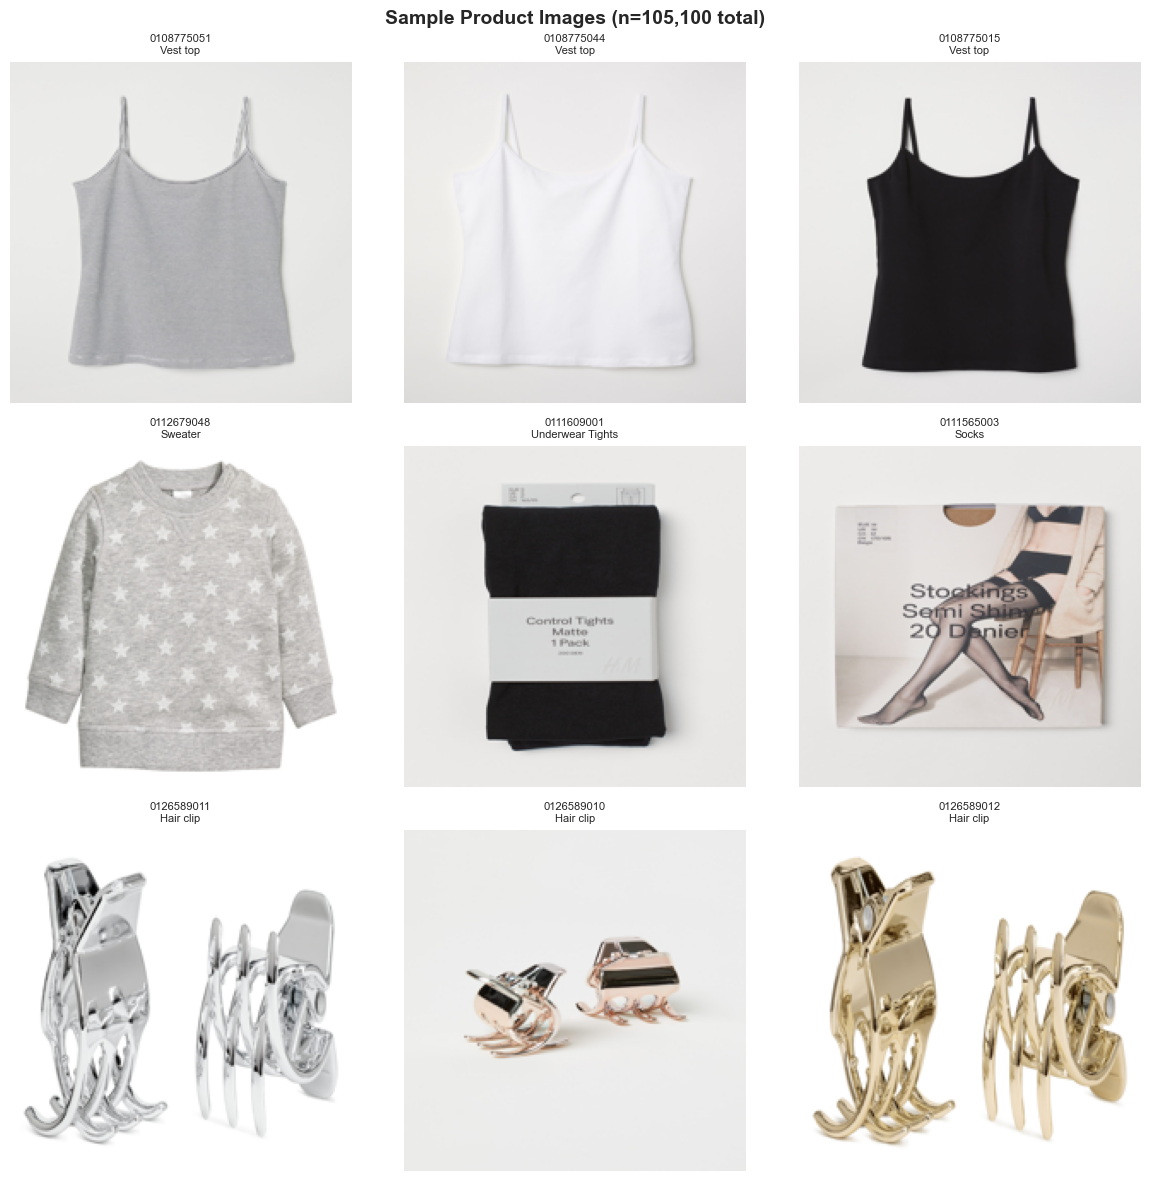

In [26]:
import os

image_dir = DATA_DIR / "images"
image_subdirs = sorted([d for d in image_dir.iterdir() if d.is_dir()])
total_images = sum(len(list(d.glob("*.jpg"))) for d in image_subdirs)

print(f"Image Data Statistics")
print(f"{'='*60}")
print(f"Image directories:    {len(image_subdirs)}")
print(f"Total images:         {total_images:,}")
print(f"Articles in catalog:  {n_articles:,}")
print(f"Coverage:             {total_images/n_articles:.1%}")

# Build article_id -> product_type lookup
pc_map = dict(zip(df_articles['article_id'].astype(str),
                   df_articles['product_type_name']))

# Sample 9 images from different subdirectories
sample_images = []
for subdir in image_subdirs[:5]:
    sample_images.extend(list(subdir.glob("*.jpg"))[:3])
sample_images = sample_images[:9]

if sample_images:
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle(f'Sample Product Images (n={total_images:,} total)',
                 fontsize=14, fontweight='bold')
    for ax, img_path in zip(axes.flat, sample_images):
        img = Image.open(img_path).resize((200, 200))
        ax.imshow(np.array(img))
        stem = img_path.stem
        ptype = pc_map.get(stem, pc_map.get(stem.lstrip('0'), 'Unknown'))
        ax.set_title(f'{stem}\n{ptype}', fontsize=8)
        ax.axis("off")
    for ax in axes.flat[len(sample_images):]:
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "00_eda_image_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Key Findings Summary

| # | Dimension | Finding | Quantitative Detail | Research Implication |
|---|-----------|---------|---------------------|----------------------|
| 1 | SKU Structure | 47K products -> 105K SKUs | Avg 2.2 variants/product | `product_code`-level LLM extraction (47K calls) covers all SKUs; L1 attributes shared within product family |
| 2 | Sparsity + Segment Imbalance | Extremely sparse matrix compounded by Pareto segment distribution | 99.98% sparse; Heavy(24.4% users) → 73.5% txn, Light(32.1%) → 3.2% txn | CF models biased toward Heavy users; 436K Light users receive degraded recommendations due to noisy embeddings — KAR factual expert (L1+L2+L3 text encoding) provides dense representations independent of interaction volume |
| 3 | Cold-start Users | Light segment (1-4 purchases) represents triple-sparsity problem | 32.1% of users, <0.004% catalog interaction per user, 99.98% matrix sparsity | User-level × matrix-level × signal quality sparsity compounds — MF/GNN cannot propagate meaningful signal; L1+L2+L3 content-based augmentation provides dense item representations without interaction dependency |
| 4 | Cold-start Items | Long-tail items lack collaborative signal | 57.3% items <100 purchases, Gini = 0.7586, Pareto: 20.7% items → 80% txn, Top-100=4.6% | All 105K items have L1+L2+L3 attribute vectors (BGE-base 768-dim) regardless of interaction history; Faiss HNSW enables <5ms ANN retrieval that completely bypasses CF signal for tail items |
| 5 | Repeat Purchases | Most user-item pairs are single-purchase | 87% single-purchase pairs | 87% single-purchase makes repeat prediction trivially "No" for majority class — uninformative. Fashion is discovery-oriented (users buy **different** items); reasoning expert infers latent preferences (style affinity, occasion, complementary) via L2+L3 semantic bridge |
| 6 | Preference Diversity | Users explore multiple product types | Avg ~7.6 unique types/user | L3 (occasion/theory) attributes can capture cross-category outfit-level preferences |
| 7 | Channel | In-store dominates | In-store ~70%, Online ~30% | In-store 주도; Online(30%) 서브셋에서 sequential modeling 적용 가능 |
| 8 | Temporal | Seasonality + COVID shift | Summer peaks, Mar 2020 dip, Apr recovery | Time-aware features needed; temporal split avoids data leakage |
| 9 | Category Bias | Ladieswear dominates transactions | ~60%+ of all transactions | Class-balanced sampling or loss weighting may be needed; diversity loss term in training |
| 10 | Image Coverage | Near-complete product images | ~105K images, ~100% coverage | Multimodal (GPT-4o-mini) L2/L3 extraction feasible for full catalog |
| 11 | Data Quality | Customer table has significant nulls | FN, Active, age, club_status nullable | Imputation or null-aware features needed; price values are Kaggle-normalized (not raw SEK) |
| 12 | detail_desc Quality | Rich text descriptions with material/construction info | Near-complete coverage, rich keyword density | LLM L1 extraction feasible for full catalog; material + fit + construction keywords provide strong signal |
| 13 | Product Lifecycle | Wide lifespan range from seasonal to perennial | Short-lived (<30d) vs long-lived (>365d) coexist | Short-lived items are cold-start candidates; monthly new item rate informs attribute refresh cadence |
| 14 | Age × Category | Age groups show distinct product type preferences | Preference heatmap shows clear age-dependent patterns | User profiling should incorporate age-aware features; KAR reasoning expert can model demographic preferences |
| 15 | Basket Patterns | Multi-item same-day purchases are common | Top co-purchase pairs reveal outfit-level behavior | L3 attributes should model complementary relationships; basket-aware candidate generation can improve diversity |
| 16 | Split Overlap | New users/items appear in Val/Test | Quantified new user/item rates per split | Content-based L1+L2+L3 essential for cold-start in evaluation; recency distribution validates temporal split design |

In [27]:
con.close()
print("EDA complete.")

EDA complete.
